In [1]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
#import cmasher as cmr
import matplotlib.colors as mcolors
import mplcursors

In [2]:
import IPython
notebook_name = "/".join(
        IPython.extract_module_locals()[1]["__vsc_ipynb_file__"].split("/")[-5:]
    )
print(notebook_name)

hgrup_vsun/USOS_shared/Plotting/For_F0AM_runs/run30_ozone_comparison.ipynb


In [3]:
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 28
mpl.rcParams['axes.xmargin'] = 0

# Set the font family to 'serif'
mpl.rcParams['font.family'] = 'serif'
# Specify preferred serif font (Computer Modern Roman is 'cmr10')
mpl.rcParams['font.serif'] = 'Lato' 
# Optionally, configure mathtext to use Computer Modern fonts as well
mpl.rcParams['mathtext.fontset'] = 'cm'
# Ensure minus signs are rendered correctly with CM fonts
mpl.rcParams['axes.unicode_minus'] = False

#Colorblind friendly colors in RGB:
forest_green_color = np.array([51,117,56])
bright_green_color = np.array([51, 117, 56])
indigo_color = np.array([46, 37, 133])
bright_blue_color = np.array([0, 114, 178])
light_blue_color = np.array([86, 180, 233])
pale_blue_color = np.array([148, 203, 236])
yellow_orange_color = np.array([230, 159, 0])
sunny_yellow_color = np.array([230, 159, 20])
lemon_yellow_color = np.array([240, 228, 66])
bright_orange_color = np.array([93, 168, 153])
desaturated_pink_color = np.array([194, 106, 119])
saturated_orchid_color = np.array([194, 106, 119])
purple_orchid_color = np.array([159, 74, 150])


def rgb_range_correction(color_names):
    mpl_formatted_colors = []
    for c in range(0,len(color_names)):
        rgb_division = color_names[c]/255
        mpl_formatted_colors.append(rgb_division)
    return mpl_formatted_colors

trio_colorset1 = rgb_range_correction([forest_green_color, bright_blue_color, sunny_yellow_color])


In [4]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

data_date = '7_19_2024'
run_number = '30'
chemical_mechanisms = ['GEOS-Chem','CRACMM','CB6r5h']

yaml_usos_dirpath = dirpath + 'F0AM-4.4.2/Runs/USOS_' + data_date 
yaml_usos_full_filepath = yaml_usos_dirpath + '/' + 'Run' + run_number +'/USOS_' + data_date + '.yaml'

yaml_run_dirpath = dirpath + 'F0AM-4.4.2/Runs/USOS_' + data_date + '/Run' + run_number + '/'
yaml_run_geoschem_full_filepath = yaml_run_dirpath + chemical_mechanisms[0] + '/' + 'USOS_' + data_date + 'run_output_python.yaml'
yaml_run_cracmm_full_filepath = yaml_run_dirpath + chemical_mechanisms[1] + '/' + 'USOS_' + data_date + 'run_output_python.yaml'
yaml_run_cb_full_filepath = yaml_run_dirpath + chemical_mechanisms[2] + '/' + 'USOS_' + data_date + 'run_output_python.yaml'

In [5]:
with open(yaml_usos_full_filepath, 'r') as f:
    yaml_usos = yaml.full_load(f)

with open(yaml_run_geoschem_full_filepath, 'r') as f:
    yaml_geoschem = yaml.full_load(f)

with open(yaml_run_cracmm_full_filepath, 'r') as f:
    yaml_cracmm = yaml.full_load(f)

with open(yaml_run_cb_full_filepath, 'r') as f:
    yaml_cb = yaml.full_load(f)

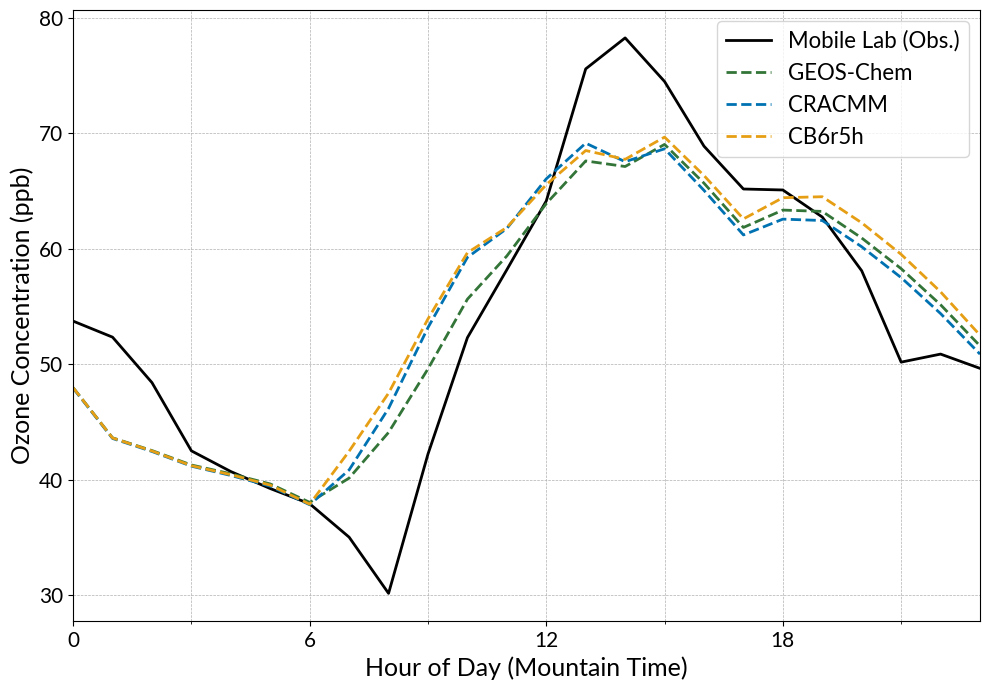

In [9]:
fig, ax = plt.subplots(figsize = (10,7), layout = 'tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]
hour_range = np.arange(0,24,1)
plt.plot(hour_range, yaml_usos['O3_ppbv'], label = 'Mobile Lab (Obs.)', linestyle = 'solid', linewidth = 2, color = 'black')
plt.plot(hour_range, yaml_geoschem['Conc']['O3'], label = 'GEOS-Chem', linestyle = 'dashed', linewidth = 2, color = trio_colorset1[0].tolist())
plt.plot(hour_range, yaml_cracmm['Conc']['O3'], label = 'CRACMM', linestyle = 'dashed', linewidth = 2, color = trio_colorset1[1].tolist())
plt.plot(hour_range, yaml_cb['Conc']['O3'], label = 'CB6r5h', linestyle = 'dashed', linewidth = 2, color = trio_colorset1[2].tolist())
ax.xaxis.set_minor_locator(MultipleLocator(3))
ax.xaxis.set_major_locator(MultipleLocator(6))
ax.grid(which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Hour of Day (Mountain Time)')
# plt.xticks(np.arange(0,24))
plt.margins(x=0)

plt.ylabel('Ozone Concentration (ppb)')
plt.legend()
#plt.title('Ozone Between Chemical Mechanisms \nfor July 19, 2024\n')
plt.savefig(dirpath + '/Plotting/For_F0AM_runs/initial_F0AM_ozone_Comparison_2024719.png', dpi =150)
plt.show()

In [7]:
#Normalized Mean Bias Factor
print(type(yaml_geoschem['Conc']['O3']))

<class 'list'>


In [7]:
mech_name = ['GEOS-Chem', 'CRACMM', 'CB6r5h']
model_results = np.array([yaml_geoschem['Conc']['O3'], yaml_cracmm['Conc']['O3'], yaml_cb['Conc']['O3']])
obs = yaml_usos['O3_ppbv']
length_of_data = len(obs)
one_over_length_of_data = 1/length_of_data

normalized_mean_bias_list = []
nmbf_list = []
mean_bias_list = []

for mech in range(0,len(model_results)):
    model_obs_diff = model_results[mech] - obs
    sum_of_differences = np.sum(model_obs_diff)
    sum_obs = np.sum(obs)
    nmb = sum_of_differences/sum_obs
    normalized_mean_bias_list.append(nmb)

    print(mech_name[mech] + ' NMB:', nmb)
    print(nmb*100)

    bias_factor_num = one_over_length_of_data * (np.sum(model_results[mech]))
    bias_factor_den = one_over_length_of_data * (np.sum(obs))
    bias_factor = bias_factor_num/bias_factor_den
    nmbf = bias_factor - 1
    nmbf_list.append(nmbf)

    print(mech_name[mech]+' NMBF:', nmbf)

    mean_bias = one_over_length_of_data*sum_of_differences
    print(mech_name[mech]+' Mean Bias:', mean_bias)

    mean_absolute_error = one_over_length_of_data*np.sum(abs(model_obs_diff))
    print(mech_name[mech]+' Mean Absolute Error:', mean_absolute_error, '\n')

GEOS-Chem NMB: -0.004420662648660574
-0.4420662648660574
GEOS-Chem NMBF: -0.004420662648660589
GEOS-Chem Mean Bias: -0.23871038007153916
GEOS-Chem Mean Absolute Error: 4.333628503789557 

CRACMM NMB: 0.0028381996066101146
0.28381996066101145
CRACMM NMBF: 0.0028381996066100257
CRACMM Mean Bias: 0.15325930989510655
CRACMM Mean Absolute Error: 4.814456907821476 

CB6r5h NMB: 0.017375545828439795
1.7375545828439796
CB6r5h NMBF: 0.017375545828439698
CB6r5h Mean Bias: 0.9382582382562124
CB6r5h Mean Absolute Error: 5.125476226815241 



GEOS-Chem underestimates O$_3$ by 0.44%, while CRACMM and CB6r5h overpredicts O$_3$ by 0.28% and 1.7%. 

GEOS-Chem predicts values 0.24 ppbv lower than the observations.
CRACMM predicts values 0.15 ppb higher than the observations.
CB6r5h predicts values 0.93 ppb higher than the observations. 

The average size of the error for GEOS-Chem from the observations is 4.33 ppbv.
The average size of the error for CRACMM from the observations is 4.8 ppbv.
The average size of the error for CB6r5h from the observations is 5.1 ppbv.

In [19]:
mech_name = ['GEOS-Chem', 'CRACMM', 'CB6r5h']
model_results_daytime = np.array([yaml_geoschem['Conc']['O3'][6:19], yaml_cracmm['Conc']['O3'][6:19], yaml_cb['Conc']['O3'][6:19]])

obs_daytime = yaml_usos['O3_ppbv'][6:19]
length_of_data = len(obs_overnight)
one_over_length_of_data = 1/length_of_data

normalized_mean_bias_list_daytime = []
nmbf_list_daytime = []
mean_bias_list_daytime = []


for mech in range(0,len(model_results_daytime)):
    mech_name = ['GEOS-Chem', 'CRACMM', 'CB6r5h']
model_results_daytime = np.array([yaml_geoschem['Conc']['O3'][6:19], yaml_cracmm['Conc']['O3'][6:19], yaml_cb['Conc']['O3'][6:19]])

obs_daytime = yaml_usos['O3_ppbv'][6:19]
length_of_data = len(obs_daytime)
one_over_length_of_data = 1/length_of_data

normalized_mean_bias_list_daytime = []
nmbf_list_daytime = []
mean_bias_list_daytime = []


for mech in range(0,len(model_results_daytime)):
    model_obs_diff_daytime = model_results_daytime[mech] - obs_daytime
    sum_of_differences_daytime = np.sum(model_obs_diff_daytime)
    sum_obs_daytime = np.sum(obs_daytime)
    nmb_daytime = sum_of_differences_daytime/sum_obs_daytime
    normalized_mean_bias_list_daytime.append(nmb_daytime)

    print(mech_name[mech] + ' NMB:', nmb_daytime)
    print(nmb_daytime*100)

    bias_factor_num_daytime = one_over_length_of_data * (np.sum(model_results_daytime[mech]))
    bias_factor_den_daytime = one_over_length_of_data * (np.sum(obs_daytime))
    bias_factor_daytime = bias_factor_num_daytime/bias_factor_den_daytime
    nmbf_daytime = bias_factor_daytime - 1
    nmbf_list_daytime.append(nmbf_daytime)

    print(mech_name[mech]+' NMBF:', nmbf_daytime)

    mean_bias_daytime = one_over_length_of_data*sum_of_differences_daytime
    print(mech_name[mech]+' Mean Bias:', mean_bias_daytime)

    mean_absolute_error_daytime = one_over_length_of_data*np.sum(abs(model_obs_diff_daytime))
    print(mech_name[mech]+' Mean Absolute Error:', mean_absolute_error_daytime, '\n')

GEOS-Chem NMB: -0.0026592572237491164
-0.26592572237491163
GEOS-Chem NMBF: -0.0026592572237491563
GEOS-Chem Mean Bias: -0.15290494939446558
GEOS-Chem Mean Absolute Error: 4.935945097337901 

CRACMM NMB: 0.01583753782002818
1.583753782002818
CRACMM NMBF: 0.015837537820027947
CRACMM Mean Bias: 0.9106444827064271
CRACMM Mean Absolute Error: 6.051445346281631 

CB6r5h NMB: 0.027675871124276837
2.767587112427684
CB6r5h NMBF: 0.02767587112427683
CB6r5h Mean Bias: 1.5913382262958333
CB6r5h Mean Absolute Error: 5.938234108233051 



In [15]:
mech_name = ['GEOS-Chem', 'CRACMM', 'CB6r5h']
model_results_overnight = np.array([yaml_geoschem['Conc']['O3'][0:6], yaml_cracmm['Conc']['O3'][0:6], yaml_cb['Conc']['O3'][0:6]])
model_results_morning = np.array([yaml_geoschem['Conc']['O3'][6:12], yaml_cracmm['Conc']['O3'][6:12], yaml_cb['Conc']['O3'][6:12]])
model_results_afternoon = np.array([yaml_geoschem['Conc']['O3'][12:18], yaml_cracmm['Conc']['O3'][12:18], yaml_cb['Conc']['O3'][12:18]])
model_results_evening = np.array([yaml_geoschem['Conc']['O3'][18:24], yaml_cracmm['Conc']['O3'][18:24], yaml_cb['Conc']['O3'][18:24]])

obs_overnight = yaml_usos['O3_ppbv'][0:6]
obs_morning = yaml_usos['O3_ppbv'][6:12]
obs_afternoon = yaml_usos['O3_ppbv'][12:18]
obs_evening = yaml_usos['O3_ppbv'][18:24]
length_of_data = len(obs_overnight)
one_over_length_of_data = 1/length_of_data

normalized_mean_bias_list_overnight = []
nmbf_list_overnight = []
mean_bias_list_overnight = []
normalized_mean_bias_list_morning = []
nmbf_list_morning = []
mean_bias_list_morning = []
normalized_mean_bias_list_afternoon = []
nmbf_list_afternoon = []
mean_bias_list_afternoon = []
normalized_mean_bias_list_evening = []
nmbf_list_evening = []
mean_bias_list_evening = []

for mech in range(0,len(model_results_overnight)):
    model_obs_diff_overnight = model_results_overnight[mech] - obs_overnight
    sum_of_differences_overnight = np.sum(model_obs_diff_overnight)
    sum_obs_overnight = np.sum(obs_overnight)
    nmb_overnight = sum_of_differences_overnight/sum_obs_overnight
    normalized_mean_bias_list_overnight.append(nmb_overnight)

    print(mech_name[mech] + ' NMB:', nmb_overnight)
    print(nmb_overnight*100)

    bias_factor_num_overnight = one_over_length_of_data * (np.sum(model_results_overnight[mech]))
    bias_factor_den_overnight = one_over_length_of_data * (np.sum(obs_overnight))
    bias_factor_overnight = bias_factor_num_overnight/bias_factor_den_overnight
    nmbf_overnight = bias_factor_overnight - 1
    nmbf_list_overnight.append(nmbf_overnight)

    print(mech_name[mech]+' NMBF:', nmbf_overnight)

    mean_bias_overnight = one_over_length_of_data*sum_of_differences_overnight
    print(mech_name[mech]+' Mean Bias:', mean_bias_overnight)

    mean_absolute_error_overnight = one_over_length_of_data*np.sum(abs(model_obs_diff_overnight))
    print(mech_name[mech]+' Mean Absolute Error:', mean_absolute_error_overnight, '\n')

GEOS-Chem NMB: -0.07724677129482634
-7.724677129482633
GEOS-Chem NMBF: -0.07724677129482627
GEOS-Chem Mean Bias: -3.5652188724261196
GEOS-Chem Mean Absolute Error: 3.698294895098139 

CRACMM NMB: -0.07947783030673726
-7.947783030673726
CRACMM NMBF: -0.07947783030673705
CRACMM Mean Bias: -3.668190343743704
CRACMM Mean Absolute Error: 3.7377296277049 

CB6r5h NMB: -0.07834119851665958
-7.834119851665958
CB6r5h NMBF: -0.07834119851665944
CB6r5h Mean Bias: -3.615730661079195
CB6r5h Mean Absolute Error: 3.7148668822929496 



In [16]:
for mech in range(0,len(model_results_morning)):
    model_obs_diff_morning = model_results_morning[mech] - obs_morning
    sum_of_differences_morning = np.sum(model_obs_diff_morning)
    sum_obs_morning = np.sum(obs_morning)
    nmb_morning = sum_of_differences_morning/sum_obs_morning
    normalized_mean_bias_list_morning.append(nmb_morning)

    print(mech_name[mech] + ' NMB:', nmb_morning)
    print(nmb_morning*100)

    bias_factor_num_morning = one_over_length_of_data * (np.sum(model_results_morning[mech]))
    bias_factor_den_morning = one_over_length_of_data * (np.sum(obs_morning))
    bias_factor_morning = bias_factor_num_morning/bias_factor_den_morning
    nmbf_morning = bias_factor_morning - 1
    nmbf_list_morning.append(nmbf_morning)

    print(mech_name[mech]+' NMBF:', nmbf_morning)

    mean_bias_morning = one_over_length_of_data*sum_of_differences_morning
    print(mech_name[mech]+' Mean Bias:', mean_bias_morning)

    mean_absolute_error_morning = one_over_length_of_data*np.sum(abs(model_obs_diff_morning))
    print(mech_name[mech]+' Mean Absolute Error:', mean_absolute_error_morning, '\n')

GEOS-Chem NMB: 0.12154017604791403
12.154017604791404
GEOS-Chem NMBF: 0.12154017604791378
GEOS-Chem Mean Bias: 5.181626826938722
GEOS-Chem Mean Absolute Error: 5.181626826938722 

CRACMM NMB: 0.16907579784125684
16.907579784125684
CRACMM NMBF: 0.1690757978412567
CRACMM Mean Bias: 7.208214751432891
CRACMM Mean Absolute Error: 7.237040881999296 

CB6r5h NMB: 0.18567287791076473
18.567287791076474
CB6r5h NMBF: 0.1856728779107646
CB6r5h Mean Bias: 7.915798680742889
CB6r5h Mean Absolute Error: 7.928373001402556 



In [17]:
for mech in range(0,len(model_results_afternoon)):
    model_obs_diff_afternoon = model_results_afternoon[mech] - obs_afternoon
    sum_of_differences_afternoon = np.sum(model_obs_diff_afternoon)
    sum_obs_afternoon = np.sum(obs_afternoon)
    nmb_afternoon = sum_of_differences_afternoon/sum_obs_afternoon
    normalized_mean_bias_list_afternoon.append(nmb_afternoon)

    print(mech_name[mech] + ' NMB:', nmb_afternoon)
    print(nmb_afternoon*100)

    bias_factor_num_afternoon = one_over_length_of_data * (np.sum(model_results_afternoon[mech]))
    bias_factor_den_afternoon = one_over_length_of_data * (np.sum(obs_afternoon))
    bias_factor_afternoon = bias_factor_num_afternoon/bias_factor_den_afternoon
    nmbf_afternoon = bias_factor_afternoon - 1
    nmbf_list_afternoon.append(nmbf_afternoon)

    print(mech_name[mech]+' NMBF:', nmbf_afternoon)

    mean_bias_afternoon = one_over_length_of_data*sum_of_differences_afternoon
    print(mech_name[mech]+' Mean Bias:', mean_bias_afternoon)

    mean_absolute_error_afternoon = one_over_length_of_data*np.sum(abs(model_obs_diff_afternoon))
    print(mech_name[mech]+' Mean Absolute Error:', mean_absolute_error_afternoon, '\n')

GEOS-Chem NMB: -0.073457664085782
-7.3457664085782
GEOS-Chem NMBF: -0.07345766408578192
GEOS-Chem Mean Bias: -5.222732542059397
GEOS-Chem Mean Absolute Error: 5.222732542059397 

CRACMM NMB: -0.067711935966362
-6.7711935966362
CRACMM NMBF: -0.06771193596636194
CRACMM Mean Bias: -4.814219671406751
CRACMM Mean Absolute Error: 5.4534920007820205 

CB6r5h NMB: -0.061268682820059615
-6.126868282005962
CB6r5h NMBF: -0.061268682820059484
CB6r5h Mean Bias: -4.356113790928128
CB6r5h Mean Absolute Error: 4.82601550026193 



In [18]:
for mech in range(0,len(model_results_evening)):
    model_obs_diff_evening = model_results_evening[mech] - obs_evening
    sum_of_differences_evening = np.sum(model_obs_diff_evening)
    sum_obs_evening = np.sum(obs_evening)
    nmb_evening = sum_of_differences_evening/sum_obs_evening
    normalized_mean_bias_list_evening.append(nmb_evening)

    print(mech_name[mech] + ' NMB:', nmb_evening)
    print(nmb_evening*100)

    bias_factor_num_evening = one_over_length_of_data * (np.sum(model_results_evening[mech]))
    bias_factor_den_evening = one_over_length_of_data * (np.sum(obs_evening))
    bias_factor_evening = bias_factor_num_evening/bias_factor_den_evening
    nmbf_evening = bias_factor_evening - 1
    nmbf_list_evening.append(nmbf_evening)

    print(mech_name[mech]+' NMBF:', nmbf_evening)

    mean_bias_evening = one_over_length_of_data*sum_of_differences_evening
    print(mech_name[mech]+' Mean Bias:', mean_bias_evening)

    mean_absolute_error_evening = one_over_length_of_data*np.sum(abs(model_obs_diff_evening))
    print(mech_name[mech]+' Mean Absolute Error:', mean_absolute_error_evening, '\n')

GEOS-Chem NMB: 0.04725516838867663
4.725516838867663
GEOS-Chem NMBF: 0.047255168388676605
GEOS-Chem Mean Bias: 2.6514830672606386
GEOS-Chem Mean Absolute Error: 3.2318597510619718 

CRACMM NMB: 0.03363456883172463
3.363456883172463
CRACMM NMBF: 0.033634568831724554
CRACMM Mean Bias: 1.8872325032979909
CRACMM Mean Absolute Error: 2.8295651207996864 

CB6r5h NMB: 0.06788602904712494
6.788602904712494
CB6r5h NMBF: 0.06788602904712504
CB6r5h Mean Bias: 3.809078724289283
CB6r5h Mean Absolute Error: 4.032649523303528 



---

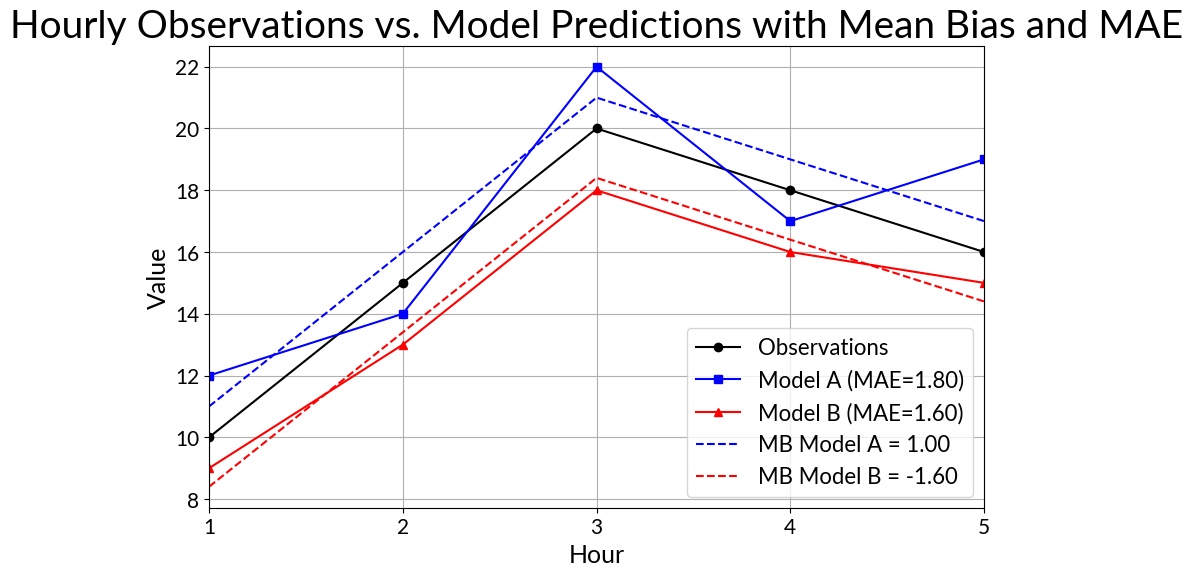

In [13]:
# Sample hourly data
hours = [1, 2, 3, 4, 5]
obs = [10, 15, 20, 18, 16]
model_a = [12, 14, 22, 17, 19]
model_b = [9, 13, 18, 16, 15]

# Compute mean bias for each model
mb_a = sum([m - o for m, o in zip(model_a, obs)]) / len(obs)
mb_b = sum([m - o for m, o in zip(model_b, obs)]) / len(obs)

# Compute Mean Absolute Error (MAE) for each model
mae_a = sum([abs(m - o) for m, o in zip(model_a, obs)]) / len(obs)
mae_b = sum([abs(m - o) for m, o in zip(model_b, obs)]) / len(obs)

# Create MB lines (horizontal lines offset by MB)
mb_line_a = [o + mb_a for o in obs]
mb_line_b = [o + mb_b for o in obs]

# Plot
plt.figure(figsize=(10,6))
plt.plot(hours, obs, 'o-', label='Observations', color='black')
plt.plot(hours, model_a, 's-', label=f'Model A (MAE={mae_a:.2f})', color='blue')
plt.plot(hours, model_b, '^-', label=f'Model B (MAE={mae_b:.2f})', color='red')
plt.plot(hours, mb_line_a, '--', label=f'MB Model A = {mb_a:.2f}', color='blue')
plt.plot(hours, mb_line_b, '--', label=f'MB Model B = {mb_b:.2f}', color='red')

plt.xlabel('Hour')
plt.ylabel('Value')
plt.title('Hourly Observations vs. Model Predictions with Mean Bias and MAE')
plt.xticks(hours)
plt.legend()
plt.grid(True)
plt.show()

1.0
<class 'list'>
[11.0, 16.0, 21.0, 19.0, 17.0]


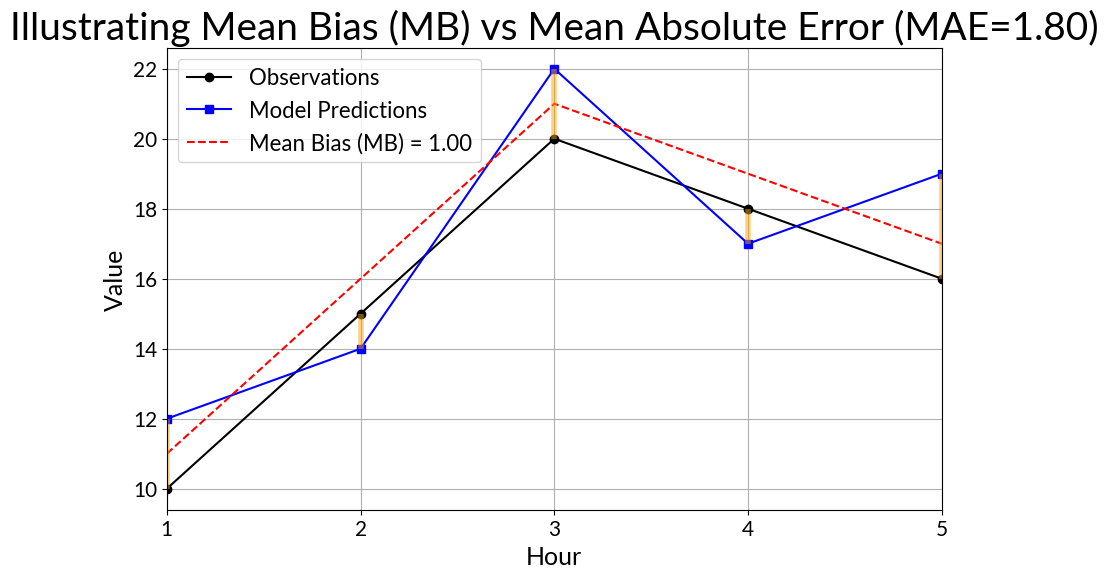

In [14]:
import matplotlib.pyplot as plt

# Sample hourly data
hours = [1, 2, 3, 4, 5]
obs = [10, 15, 20, 18, 16]
model = [12, 14, 22, 17, 19]

# Compute Mean Bias (MB)
mb = sum([m - o for m, o in zip(model, obs)]) / len(obs)
print(mb)
mb_line = [o + mb for o in obs]
print(type(mb_line))
print(mb_line)

# Compute MAE
mae = sum([abs(m - o) for m, o in zip(model, obs)]) / len(obs)

# Plot observations and model
plt.figure(figsize=(10,6))
plt.plot(hours, obs, 'o-', label='Observations', color='black')
plt.plot(hours, model, 's-', label='Model Predictions', color='blue')

# Plot Mean Bias line
plt.plot(hours, mb_line, '--', label=f'Mean Bias (MB) = {mb:.2f}', color='red')

# Show absolute errors as vertical lines (for MAE illustration)
for h, o, m in zip(hours, obs, model):
    plt.vlines(h, min(o, m), max(o, m), color='orange', alpha=0.5, linewidth=4)

plt.xlabel('Hour')
plt.ylabel('Value')
plt.title(f'Illustrating Mean Bias (MB) vs Mean Absolute Error (MAE={mae:.2f})')
plt.xticks(hours)
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1225738/4207284056.py:36: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s-" (-> marker='s'). The keyword argument will take precedence.
  plt.plot(hour_range, model_geoschem, 's-', label = 'GEOS-Chem Predicted Val', marker='x', color = trio_colorset1[0].tolist())
/tmp/ipykernel_1225738/4207284056.py:37: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s-" (-> marker='s'). The keyword argument will take precedence.
  plt.plot(hour_range, model_cracmm, 's-', label = 'CRACMM Predicted Val', marker = '*',color = trio_colorset1[1].tolist())
/tmp/ipykernel_1225738/4207284056.py:38: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s-" (-> marker='s'). The keyword argument will take precedence.
  plt.plot(hour_range, model_cb, 's-', label = 'CB6r5h Predicted Val', marker ='o', color = trio_colorset1[2].tolist())


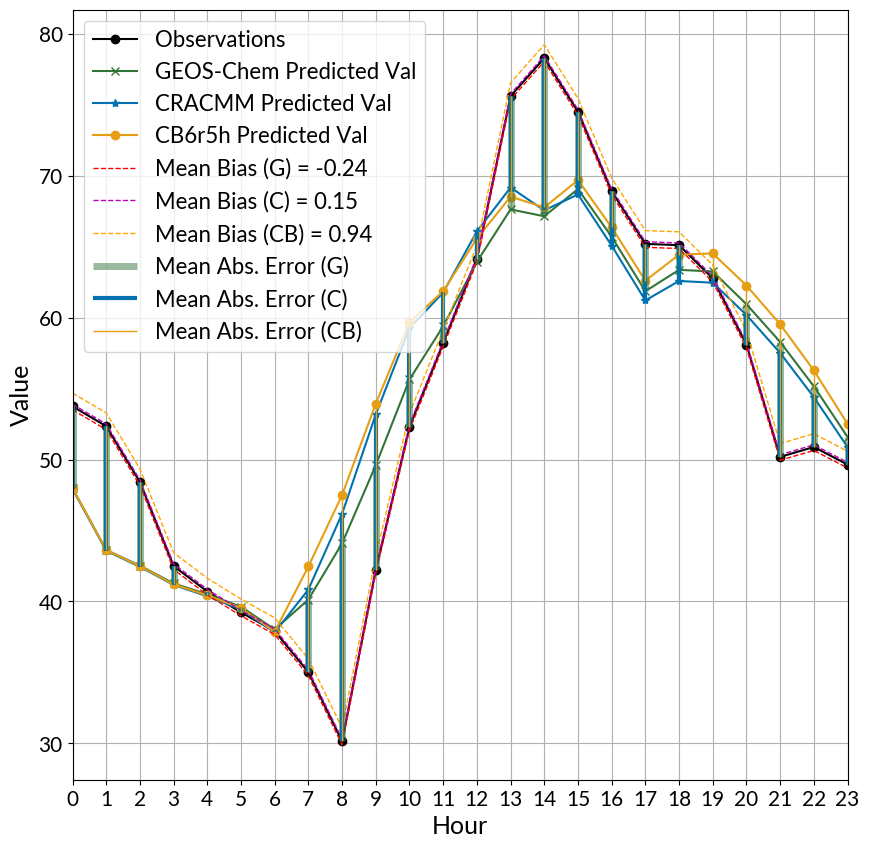

In [15]:

# hour_range = np.arange(0,24,1)
# plt.plot(hour_range, yaml_usos['O3_ppbv'], label = 'Mobile Lab (Obs.)', linestyle = 'solid', linewidth = 2, color = 'black')
# plt.plot(hour_range, yaml_geoschem['Conc']['O3'], label = 'GEOS-Chem', linestyle = 'dashed', linewidth = 2, color = trio_colorset1[0].tolist())
# plt.plot(hour_range, yaml_cracmm['Conc']['O3'], label = 'CRACMM', linestyle = 'dashed', linewidth = 2, color = trio_colorset1[1].tolist())
# plt.plot(hour_range, yaml_cb['Conc']['O3'], label = 'CB6r5h', linestyle = 'dashed', linewidth = 2, color = trio_colorset1[2].tolist())

obs = yaml_usos['O3_ppbv']
obs = [x[0] for x in obs]
model_geoschem = yaml_geoschem['Conc']['O3']
model_geoschem = [x[0] for x in model_geoschem]

model_cracmm = yaml_cracmm['Conc']['O3']
model_cracmm = [x[0] for x in model_cracmm]

model_cb = yaml_cb['Conc']['O3']
model_cb = [x[0] for x in model_cb]

# # # Compute Mean Bias (MB)
mb_geoschem = sum([m - o for m, o in zip(model_geoschem, obs)]) / len(obs)
mb_line_geoschem = [o + mb_geoschem for o in obs]

mb_cracmm = sum([m - o for m, o in zip(model_cracmm, obs)]) / len(obs)
mb_line_cracmm = [o + mb_cracmm for o in obs]

mb_cb = sum([m - o for m, o in zip(model_cb, obs)]) / len(obs)
mb_line_cb = [o + mb_cb for o in obs]

# # # Compute MAE
mae_geoschem = sum([abs(m - o) for m, o in zip(model_geoschem, obs)]) / len(obs)
mae_cracmm = sum([abs(m - o) for m, o in zip(model_cracmm, obs)]) / len(obs)
mae_cb = sum([abs(m - o) for m, o in zip(model_cb, obs)]) / len(obs)

# # Plot observations and model
plt.figure(figsize=(10,10))
plt.plot(hour_range, obs, 'o-', label='Observations', color='black')
plt.plot(hour_range, model_geoschem, 's-', label = 'GEOS-Chem Predicted Val', marker='x', color = trio_colorset1[0].tolist())
plt.plot(hour_range, model_cracmm, 's-', label = 'CRACMM Predicted Val', marker = '*',color = trio_colorset1[1].tolist())
plt.plot(hour_range, model_cb, 's-', label = 'CB6r5h Predicted Val', marker ='o', color = trio_colorset1[2].tolist())

# # Plot Mean Bias line
plt.plot(hour_range, mb_line_geoschem, '--', label=f'Mean Bias (G) = {mb_geoschem:.2f}', color='red', linewidth = 1)
plt.plot(hour_range, mb_line_cracmm, '--', label=f'Mean Bias (C) = {mb_cracmm:.2f}', color='m', linewidth = 1)
plt.plot(hour_range, mb_line_cb, '--', label=f'Mean Bias (CB) = {mb_cb:.2f}', color='orange', linewidth = 1)

# Show absolute errors as vertical lines (for MAE illustration)
for h, o, m in zip(hour_range, obs, model_geoschem):
    if h== 0:
        plt.vlines(h, min(o, m), max(o, m), color=trio_colorset1[0].tolist(), alpha=0.5, linewidth=5, label = 'Mean Abs. Error (G)')
    else:
        plt.vlines(h, min(o, m), max(o, m), color=trio_colorset1[0].tolist(), alpha=0.5, linewidth=5)
for h, o, m in zip(hour_range, obs, model_cracmm):
    if h ==0:
        plt.vlines(h, min(o, m), max(o, m), color=trio_colorset1[1].tolist(), alpha=1, linewidth=3, label = 'Mean Abs. Error (C)')
    else:
        plt.vlines(h, min(o, m), max(o, m), color=trio_colorset1[1].tolist(), alpha=1, linewidth=3)
for h, o, m in zip(hour_range, obs, model_cb):
    if h == 0:
        plt.vlines(h, min(o, m), max(o, m), color=trio_colorset1[2].tolist(), alpha=1, linewidth=1, label = 'Mean Abs. Error (CB)')
    else:
        plt.vlines(h, min(o, m), max(o, m), color=trio_colorset1[2].tolist(), alpha=1, linewidth=1)

plt.xlabel('Hour')
plt.ylabel('Value')
# plt.title(f'Illustrating Mean Bias (MB) vs Mean Absolute Error (MAE={mae:.2f})')
plt.xticks(hour_range)
plt.legend()
plt.grid(True)
plt.show()

---

In [3]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

data_date = '7_19_2024'
run_number = '30'
chemical_mechanisms = ['GEOS-Chem','CRACMM','CB6r5h']

yaml_run_dirpath = dirpath + 'F0AM-4.4.2/Runs/USOS_' + data_date + '/Run' + run_number + '/'

ozone_yaml_geoschem_dirpath = yaml_run_dirpath + chemical_mechanisms[0] + '/' 
ozone_yaml_run_geoschem_full_filepath = ozone_yaml_geoschem_dirpath + 'USOS_' + data_date + '_' + chemical_mechanisms[0] +  '_Run' + run_number + '_ozone_production_output.yaml'

ozone_yaml_cracmm_dirpath = yaml_run_dirpath + chemical_mechanisms[1] + '/' 
ozone_yaml_run_cracmm_full_filepath = ozone_yaml_cracmm_dirpath + 'USOS_' + data_date + '_' +  chemical_mechanisms[1] + '_Run' + run_number + '_ozone_production_output.yaml'

ozone_yaml_cb6r5h_dirpath = yaml_run_dirpath + chemical_mechanisms[2] + '/' 
ozone_yaml_run_cb6r5h_full_filepath = ozone_yaml_cb6r5h_dirpath + 'USOS_' + data_date + '_' +  chemical_mechanisms[2] + '_Run' + run_number + '_ozone_production_output.yaml'

In [4]:
with open(ozone_yaml_run_geoschem_full_filepath, 'r') as f:
    ozone_yaml_geoschem = yaml.full_load(f)

with open(ozone_yaml_run_cracmm_full_filepath, 'r') as f:
    ozone_yaml_cracmm = yaml.full_load(f)

with open(ozone_yaml_run_cb6r5h_full_filepath, 'r') as f:
    ozone_yaml_cb6r5h = yaml.full_load(f)

In [5]:
print(ozone_yaml_geoschem.keys())

dict_keys(['O3rates', 'O3netrate', 'mech_RO2s', 'RO2_NO_conversion_rxns', 'RO2_NO_scaled_rates', 'RO2_NO_conversion_sum_rates', 'grouped_voc_ozone_production', 'HO2_NO_rate', 'ope_numerator', 'NOx_to_res_conversion_rxns', 'lost_NOx_multiply_rates', 'lost_NOx_sum_rates', 'ope_total'])


In [36]:
print(ozone_yaml_cb6r5h['RO2_NO_conversion_rxns'])

['C2O3 + NO = MEO2+ NO2+ RO2', 'CXO3 + NO = ALD2+ XO2H+ NO2+ RO2', 'MEO2 + NO = FORM+ NO2+ HO2', 'HCO3 + NO = FACD+ NO2+ HO2', 'ISO2 + NO = 0.673FORM+ 0.1INTR+ 0.9ISPD+ 0.082XO2H+ 0.9NO2+ 0.082RO2+ 0.818HO2', 'EPX2 + NO = 0.375FORM+ 0.275GLY+ 0.275GLYD+ 0.275MGLY+ 2.175PAR+ NO2+ 0.251CO+ 0.125OH+ 0.825HO2', 'BZO2 + NO = 0.918GLY+ 0.082NTR2+ 0.918OPEN+ 0.918NO2+ 0.918HO2', 'NO + TO2 = 0.417GLY+ 0.443MGLY+ 0.14NTR2+ 0.66OPEN+ 0.2XOPN+ 0.86NO2+ 0.86HO2', 'NO + XLO2 = 0.221GLY+ 0.675MGLY+ 0.14NTR2+ 0.3OPEN+ 0.56XOPN+ 0.86NO2+ 0.86HO2', 'NO + OPO3 = 0.2CXO3+ 0.5GLY+ NO2+ 0.5CO+ 0.8HO2']


In [5]:
# print(ozone_yaml_geoschem.keys())
# print(ozone_yaml_geoschem['RO2_NO_conversion_rxns'])

RO2_labels_geoschem = []
RO2_labels_cb6r5h = []

for rxn in ozone_yaml_geoschem['RO2_NO_conversion_rxns']:
    species = rxn.split('+NO')[0]
    RO2_labels_geoschem.append(species)

print(RO2_labels_geoschem)

['MO2', 'MCO3', 'ETO2', 'OTHRO2', 'A3O2', 'PO2', 'R7O2', 'R7N1', 'BUTO2', 'ACRO2', 'ACO3', 'ALK4O2', 'ALK4N1', 'R4O2', 'R4N1', 'ATO2', 'KO2', 'B3O2', 'PRN1', 'RCO3', 'KO2', 'GCO3', 'APINO2', 'PINO3', 'C96O2', 'BPINO2', 'BPINOO2', 'LIMO2', 'LIMKO2', 'LIMO3', 'PIO2', 'IHOO1', 'IHOO1', 'IHOO4', 'IHOO4', 'IHPOO1', 'IHPOO2', 'IHPOO3', 'ICHOO', 'ISOPNOO1', 'ISOPNOO2', 'IDHNDOO1', 'IDHNDOO2', 'IDHNBOO', 'INO2B', 'INO2D', 'IHPNBOO', 'IHPNDOO', 'C4HVP1', 'C4HVP2', 'MVKOHOO', 'MCROHOO', 'MACR1OO', 'ZRO2', 'ETOO', 'AROMRO2', 'AROMCO3', 'BZCO3', 'BENZO2']


In [6]:
#indices for each mechanisms' categories
#Red
aldehydes_geoschem = [9, 48, 49, 51, 52]
aldehydes_cracmm = [24, 25, 27]

#Orange
alkanes_geoschem = [2, 4, 6, 11, 12]
alkanes_cracmm = [2, 3, 4, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]

#Pink
alkenes_geoschem = [5, 18, 54]
alkenes_cracmm = [5, 6, 7]

#Light Purple
aromatic_aldehydes_geoschem = [57]
aromatic_aldehydes_cracmm= [28, 29]

#Blue
aromatics_geoschem = [53, 55, 56, 58]
benzene_cracmm = [8]
toluene_cracmm = [9]
xylene_cracmm = [10]
aromatics_cracmm = [8, 9, 10, 11, 49, 50, 51, 52]
benzene_cb = [6]
toluene_cb = [7]
xylene_cb = [8]
aromatics_cb = [6, 7, 8, 9]

#Light Brown
dienes_geoschem = [8]
dienes_cracmm = [31, 32]

#Dark Brown
acetic_acid_cracmm = [30]

#Yellow
isoprene_geoschem = [31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47]
isoprene_cracmm = [0]
isoprene_cb = [4, 5]

#Dark Purple
ketones_geoschem = [15, 16, 20, 50]
ketones_cracmm = [22, 23, 26]

#Black
methylperoxy_radical_geoschem = [0]
methylperoxy_radical_cracmm = [1]
methylperoxy_radical_cb = [2]

#Green
alphapinene_geoschem = [22, 23, 24]
betapinene_geoschem = [25, 26]
limonene_geoschem =  [27, 28, 29]
monoterpenes_geoschem = [22, 23, 24, 25, 26, 27, 28, 29, 30]
alphapinene_cracmm = [12, 13, 14, 15]
limonene_cracmm = [16, 17, 18, 19]
monoterpenes_cracmm = [12, 13, 14, 15, 16, 17, 18, 19]
sesquiterpenes_cracmm = [33, 34]

#Light Grey
peroxyacetyl_radical_geoschem =  [1]
peroxyacetyl_radical_cracmm =  [20]
peroxyacetyl_radical_cb =  [0]


In [7]:
geoschem_category_indices = {
    'Aldehydes': [9, 48, 49, 51, 52],
    'Alkanes': [2, 4, 6, 11, 12],
    'Alkenes': [5, 18, 54],
    'Benzaldehyde': [57],
    'Aromatics':[53, 55, 56, 58],
    'Dienes': [8],
    'Isoprene': [31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47],
    'Ketones': [15, 16, 20, 50],
    'Methylperoxy Radical': [0],
    'Monoterpenes': [22, 23, 24, 25, 26, 27, 28, 29, 30],
    'Peroxyacetyl Radical': [1]
}

geoschem_subcategories_indices = {
    'Alpha Pinene': [22, 23, 24],
    'Beta Pinene': [25, 26],
    'Limonene': [27, 28, 29],
    'Mix of Monoterpenes \n(alpha & beta pinene, sabinene, carene)': [30]
}

In [8]:
geoschem_category_colors = {
    'Aldehydes': 'xkcd:red',
    'Alkanes': 'xkcd:yellow',
    'Alkenes': 'xkcd:pale magenta',
    'Benzaldehyde': 'xkcd:baby purple',
    'Aromatics': 'xkcd:sky',
    'Dienes': 'xkcd:light brown',
    'Isoprene': 'xkcd:orange',
    'Ketones': 'xkcd:vivid purple',
    'Methylperoxy Radical': 'black',
    'Monoterpenes':'xkcd:tree green',
    'Peroxyacetyl Radical': 'xkcd:light grey'
}

geoschem_subcategory_colors = {
    'Alpha Pinene': 'xkcd:light lime green',
    'Beta Pinene': 'xkcd:bright green',
    'Limonene': 'xkcd:irish green',
    'Mix of Monoterpenes \n(alpha & beta pinene, sabinene, carene)': 'xkcd:dark green'
}

In [9]:
def generate_shades(base_color, n, darken_factor = 0.3):
    base_rgb = np.array(mcolors.to_rgb(base_color))
    if n == 1:
        return [mcolors.to_hex(base_rgb)]
    shades = []
    for i in range(n):
        if i == 0:
            shade_rgb = base_rgb
        factor = (i/(n-1)) * darken_factor
        shade_rgb = base_rgb * (1 - factor)
        shades.append(mcolors.to_hex(shade_rgb))
    return shades

In [10]:
n_species = len(RO2_labels_geoschem)
colors = [None] * n_species

for subcat, idxs in geoschem_subcategories_indices.items():
    base_color = geoschem_subcategory_colors.get(subcat, None)
    if base_color is None:
        cat = next(cat for cat, cidxs in geoschem_category_indices.items() if any(i in cidxs for i in idxs))
        base_color = geoschem_category_colors[cat]
    shades = generate_shades(base_color, len(idxs), darken_factor = 0.3)
    for i, idx in enumerate(idxs):
        colors[idx] = shades[i]

for cat, idxs in geoschem_category_indices.items():
    remaining = [i for i in idxs if colors[i] is None]
    if remaining:
        shades = generate_shades(geoschem_category_colors[cat], len(remaining), darken_factor = 0.3)
        for i, idx in enumerate(remaining):
            colors[idx] = shades[i]
print(colors)

['#000000', '#d8dcd6', '#ffff14', None, '#ecec12', '#d767ad', '#d9d911', None, '#ad8150', '#e50000', None, '#c6c610', '#b2b20e', None, None, '#9900fa', '#8a00e1', None, '#b75893', None, '#7a00c8', None, '#b9ff66', '#9dd957', '#82b247', '#01ff07', '#01b205', '#019529', '#017f23', '#01681d', '#033500', '#f97306', '#f47106', '#ef6e06', '#ea6c06', '#e56a06', '#e06805', '#db6505', None, '#d66305', '#d16105', '#cc5e05', '#c75c05', '#c25a05', '#bd5705', '#b85504', '#b35304', '#ae5004', '#d40000', '#c30000', '#6b00af', '#b10000', '#a00000', '#82cafc', '#964879', '#75b6e3', '#68a2ca', '#ca9bf7', '#5b8db0']


In [11]:
sum_total_voc_prod = np.sum(ozone_yaml_geoschem['RO2_NO_scaled_rates'],axis=0)
voc_fraction = (ozone_yaml_geoschem['RO2_NO_scaled_rates'] / sum_total_voc_prod)*100
n_species = voc_fraction.shape[0]
print(n_species)

59


In [12]:
index_to_label = {}
for subcat, idxs in geoschem_subcategories_indices.items():
    for i in idxs:
        index_to_label[i] = subcat
        #print(index_to_label[i])

categories_with_subs = {
    cat
    for cat, cidxs in geoschem_category_indices.items()
    for sub, sidxs in geoschem_subcategories_indices.items()
    if any(i in cidxs for i in sidxs)
}

for cat, idxs in geoschem_category_indices.items():
    if cat not in categories_with_subs:
        for idx in idxs:
            if i not in index_to_label:
                index_to_label[i] = cat

In [13]:
category_order = ['Methylperoxy Radical', 'Peroxyacetyl Radical', 'Dienes', 'Ketones', 'Aromatic aldehydes', 'Aromatics', 'Limonene', 'Beta Pinene', 'Alpha Pinene', 'Mix of Monoterpenes \n(alpha & beta pinene, sabinene, carene)', 'Alkanes','Isoprene', 'Aldehydes', 'Alkenes']
name_to_indices = {}
for subcat, idxs in geoschem_subcategories_indices.items():
    name_to_indices[subcat] = idxs
for cat, idxs in geoschem_category_indices.items():
    has_subs = any(subcat in geoschem_subcategories_indices and any(i in idxs for i in geoschem_subcategories_indices[subcat])
                    for subcat in geoschem_subcategories_indices)
    if not has_subs:
        name_to_indices[cat] = idxs
        

for i, name in enumerate(RO2_labels_geoschem):
    if i not in [idx for idxs in name_to_indices.values() for idx in idxs]:
        name_to_indices[name] = [i]
        print(name_to_indices)

seen_indices = set()

category_order_final = []
for name in category_order:
    for idx in name_to_indices.get(name, []):
        if idx not in seen_indices:
            category_order_final.append(idx)
            seen_indices.add(idx)
print(category_order_final)
print(seen_indices)
# #need to add all the species without a label into the final category order
all_indices = set(range(n_species))
print(all_indices)
for idx in range(n_species):
    if idx not in seen_indices:
        category_order_final.append(idx)
        seen_indices.add(idx)
print(category_order_final)

{'Alpha Pinene': [22, 23, 24], 'Beta Pinene': [25, 26], 'Limonene': [27, 28, 29], 'Mix of Monoterpenes \n(alpha & beta pinene, sabinene, carene)': [30], 'Aldehydes': [9, 48, 49, 51, 52], 'Alkanes': [2, 4, 6, 11, 12], 'Alkenes': [5, 18, 54], 'Benzaldehyde': [57], 'Aromatics': [53, 55, 56, 58], 'Dienes': [8], 'Isoprene': [31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47], 'Ketones': [15, 16, 20, 50], 'Methylperoxy Radical': [0], 'Peroxyacetyl Radical': [1], 'OTHRO2': [3]}
{'Alpha Pinene': [22, 23, 24], 'Beta Pinene': [25, 26], 'Limonene': [27, 28, 29], 'Mix of Monoterpenes \n(alpha & beta pinene, sabinene, carene)': [30], 'Aldehydes': [9, 48, 49, 51, 52], 'Alkanes': [2, 4, 6, 11, 12], 'Alkenes': [5, 18, 54], 'Benzaldehyde': [57], 'Aromatics': [53, 55, 56, 58], 'Dienes': [8], 'Isoprene': [31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47], 'Ketones': [15, 16, 20, 50], 'Methylperoxy Radical': [0], 'Peroxyacetyl Radical': [1], 'OTHRO2': [3], 'R7N1': [7]}
{'Alpha P

In [14]:
voc_fraction_reordered = voc_fraction[category_order_final,:]
colors_reordered = [colors[i] for i in category_order_final]
species_names = [RO2_labels_geoschem[i] for i in category_order_final]
print(colors_reordered)

['#000000', '#d8dcd6', '#ad8150', '#9900fa', '#8a00e1', '#7a00c8', '#6b00af', '#82cafc', '#75b6e3', '#68a2ca', '#5b8db0', '#019529', '#017f23', '#01681d', '#01ff07', '#01b205', '#b9ff66', '#9dd957', '#82b247', '#033500', '#ffff14', '#ecec12', '#d9d911', '#c6c610', '#b2b20e', '#f97306', '#f47106', '#ef6e06', '#ea6c06', '#e56a06', '#e06805', '#db6505', '#d66305', '#d16105', '#cc5e05', '#c75c05', '#c25a05', '#bd5705', '#b85504', '#b35304', '#ae5004', '#e50000', '#d40000', '#c30000', '#b10000', '#a00000', '#d767ad', '#b75893', '#964879', None, None, None, None, None, None, None, None, None, '#ca9bf7']


In [15]:
new_index_to_label = {}
for i, old_i in enumerate(category_order_final):
    new_index_to_label[i] = index_to_label.get(old_i, species_names[i])
    print(new_index_to_label)

{0: 'MO2'}
{0: 'MO2', 1: 'MCO3'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2', 4: 'KO2'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2', 4: 'KO2', 5: 'KO2'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2', 4: 'KO2', 5: 'KO2', 6: 'MVKOHOO'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2', 4: 'KO2', 5: 'KO2', 6: 'MVKOHOO', 7: 'ZRO2'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2', 4: 'KO2', 5: 'KO2', 6: 'MVKOHOO', 7: 'ZRO2', 8: 'AROMRO2'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2', 4: 'KO2', 5: 'KO2', 6: 'MVKOHOO', 7: 'ZRO2', 8: 'AROMRO2', 9: 'AROMCO3'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2', 4: 'KO2', 5: 'KO2', 6: 'MVKOHOO', 7: 'ZRO2', 8: 'AROMRO2', 9: 'AROMCO3', 10: 'BENZO2'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2', 4: 'KO2', 5: 'KO2', 6: 'MVKOHOO', 7: 'ZRO2', 8: 'AROMRO2', 9: 'AROMCO3', 10: 'BENZO2', 11: 'Limonene'}
{0: 'MO2', 1: 'MCO3', 2: 'BUTO2', 3: 'ATO2', 4: 'KO2', 5: 'KO2', 6: 'MVKOHOO', 7: 'ZRO2', 8: 'ARO

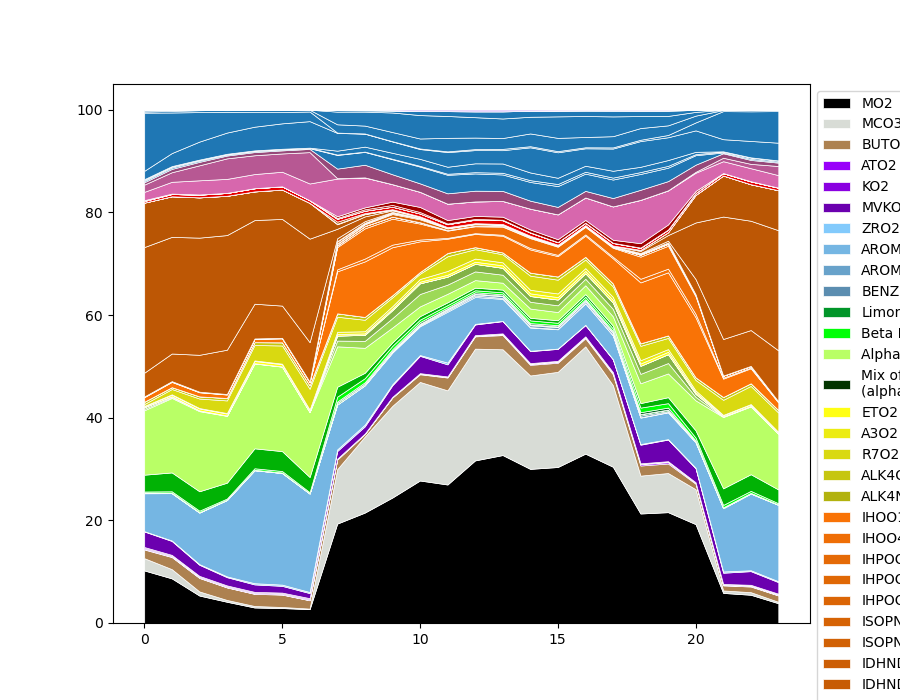

/uufs/chpc.utah.edu/common/home/u1545774/MySoftware/micromamba/envs/phdresearch/lib/python3.12/site-packages/mplcursors/_pick_info.py:145: UserWarning: Pick support for PolyCollection (MRO: PolyCollection, _CollectionWithSizes, Collection, Artist, ScalarMappable, object) is missing.
  warnings.warn(_gen_warning_text("Pick", type(artist)))


In [19]:
# import matplotlib.pyplot as plt
# import mplcursors
%matplotlib widget

hour_range = np.arange(0,24,1)
fix, ax = plt.subplots(figsize=(9,7))
stack_items = ax.stackplot(hour_range, voc_fraction_reordered, colors=colors_reordered, edgecolor = 'white', linewidth = 0.5)

handles, labels = [], []
seen = set()
for i, artist in enumerate(stack_items):
    label = new_index_to_label[i]
    if label not in seen:
        handles.append(artist)
        labels.append(label)
        seen.add(label)

ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1,1))

cursor = mplcursors.cursor(hover=True)
plt.show()

---

In [77]:
print(ozone_yaml_geoschem['RO2_NO_conversion_rxns'])

['MO2+NO=CH2O+HO2+NO2', 'MCO3+NO=MO2+NO2+CO2', 'ETO2+NO=ALD2+NO2+HO2', 'OTHRO2+NO=ALD2+NO2+HO2', 'A3O2+NO=NO2+HO2+RCHO', 'PO2+NO=NO2+HO2+CH2O+ALD2', 'R7O2+NO=NO2+0.750RCHO+0.250R4O2+0.250MEK+0.750HO2', 'R7N1+NO=2.000NO2+0.980CH2O+0.650ALD2+1.240RCHO', 'BUTO2+NO=0.058BUTN+0.730ACR+0.603CH2O+0.513HO2+0.942NO2+0.326RCHO', 'ACRO2+NO=GLYC+NO2+HO2+CO', 'ACO3+NO=HO2+CO+CH2O+NO2', 'ALK4O2+NO=NO2+0.340ACET+0.190MEK+0.190MO2+0.270HO2+0.340ALD2+0.150RCHO+0.050A3O2+0.190B3O2+0.340OTHRO2', 'ALK4N1+NO=2.000NO2+0.640RCHO+0.970ALD2+0.640CH2O', 'R4O2+NO=NO2+0.340ACET+0.190MEK+0.190MO2+0.270HO2+0.340ALD2+0.150RCHO+0.050A3O2+0.190B3O2+0.340OTHRO2', 'R4N1+NO=2.000NO2+0.640RCHO+0.970ALD2+0.640CH2O', 'ATO2+NO=NO2+CH2O+MCO3', 'KO2+NO=0.928NO2+0.919ALD2+0.919MCO3+0.072ALK4N2', 'B3O2+NO=NO2+HO2+ACET', 'PRN1+NO=2.000NO2+CH2O+ALD2', 'RCO3+NO=NO2+0.490OTHRO2+0.070A3O2+0.270B3O2+CO2', 'KO2+NO=0.930NO2+0.620ALD2+0.620MCO3+0.070R4N2+0.310MEKCO3+0.310CH2O', 'GCO3+NO=NO2+HO2+CH2O', 'APINO2+NO=0.25APINN+0.75PINAL+0.75N

In [75]:
geoschem_ro2 = RO2_labels_geoschem
data = {'GEOSChem_RO2':geoschem_ro2}
df = pd.DataFrame(data)
df.to_csv(ozone_yaml_geoschem_dirpath+'geoschem_ro2.csv', index=False)

In [73]:
RO2_labels_cracmm = []
for rxn in ozone_yaml_cracmm['RO2_NO_conversion_rxns']:
    species = rxn.split(' + NO')[0]
    RO2_labels_cracmm.append(species)

print(RO2_labels_cracmm)

['ISOP', 'MO2', 'ETHP', 'HC3P', 'HC5P', 'ETEP', 'OLTP', 'OLIP', 'BENP', 'TOLP', 'XYLP', 'EBZP', 'APIP1', 'APIP2', 'APINP1', 'APINP2', 'LIMP1', 'LIMP2', 'LIMNP1', 'LIMNP2', 'ACO3', 'RCO3', 'ACTP', 'KETP', 'MACP', 'MCP', 'MVKP', 'UALP', 'BALP', 'BAL1', 'ORAP', 'BDE13P', 'FURANO2', 'SESQNRO2', 'SESQRO2', 'VROCP6ALKP', 'VROCP5ALKP', 'VROCP4ALKP', 'VROCP3ALKP', 'VROCP2ALKP', 'VROCP1ALKP', 'HC10P', 'VROCP6ALKP2', 'VROCP5ALKP2', 'VROCP4ALKP2', 'VROCP3ALKP2', 'VROCP2ALKP2', 'VROCP1ALKP2', 'HC10P2', 'VROCP6AROP', 'VROCP5AROP', 'NAPHP', 'STYP']


In [76]:
cracmm_ro2 = RO2_labels_cracmm
data = {'CRACMM_RO2':cracmm_ro2}
df = pd.DataFrame(data)
df.to_csv(ozone_yaml_cracmm_dirpath+'cracmm_ro2.csv', index=False)

In [31]:
import re
#RO2_labels_cb6r5h = []
delimiters = [' + NO', 'NO + ']
pattern = '|'.join(re.escape(d) for d in delimiters)
RO2_labels_cb6r5h = [re.split(pattern, rxn)[0] for rxn in ozone_yaml_cb6r5h['RO2_NO_conversion_rxns']]
print(RO2_labels_cb6r5h)


['C2O3', 'CXO3', 'MEO2', 'HCO3', 'ISO2', 'EPX2', 'BZO2', '', '', '']


In [35]:
print(ozone_yaml_cb6r5h['RO2_NO_conversion_rxns'])

['C2O3 + NO = MEO2+ NO2+ RO2', 'CXO3 + NO = ALD2+ XO2H+ NO2+ RO2', 'MEO2 + NO = FORM+ NO2+ HO2', 'HCO3 + NO = FACD+ NO2+ HO2', 'ISO2 + NO = 0.673FORM+ 0.1INTR+ 0.9ISPD+ 0.082XO2H+ 0.9NO2+ 0.082RO2+ 0.818HO2', 'EPX2 + NO = 0.375FORM+ 0.275GLY+ 0.275GLYD+ 0.275MGLY+ 2.175PAR+ NO2+ 0.251CO+ 0.125OH+ 0.825HO2', 'BZO2 + NO = 0.918GLY+ 0.082NTR2+ 0.918OPEN+ 0.918NO2+ 0.918HO2', 'NO + TO2 = 0.417GLY+ 0.443MGLY+ 0.14NTR2+ 0.66OPEN+ 0.2XOPN+ 0.86NO2+ 0.86HO2', 'NO + XLO2 = 0.221GLY+ 0.675MGLY+ 0.14NTR2+ 0.3OPEN+ 0.56XOPN+ 0.86NO2+ 0.86HO2', 'NO + OPO3 = 0.2CXO3+ 0.5GLY+ NO2+ 0.5CO+ 0.8HO2']


In [66]:
#Some reactions are listed as 'NO + RO2' and others are listed as 'RO2 + NO'. Therefore, we have a multi-step splitting process to get the proper full list of RO2's at the end.
RO2_list_cb6r5h = []
for rxn in ozone_yaml_cb6r5h['RO2_NO_conversion_rxns']:
    NO_add = rxn.split(' + NO')[0].split(' = ')[0]
    if re.search(r'NO \+ ', NO_add):
        NO_split_final = NO_add.split('NO + ')[1]
        RO2_list_cb6r5h.append(NO_split_final)
    else:
        NO_add.split('NO + ')[0]
        RO2_list_cb6r5h.append(NO_add)
print(RO2_list_cb6r5h)


['C2O3', 'CXO3', 'MEO2', 'HCO3', 'ISO2', 'EPX2', 'BZO2', 'TO2', 'XLO2', 'OPO3']


In [ ]:

print(np.shape(ozone_yaml_geoschem['RO2_NO_scaled_rates']))
#print(len(ozone_yaml_geoschem['RO2_NO_conversion_sum_rates']))
print(np.shape(np.sum(ozone_yaml_geoschem['RO2_NO_scaled_rates'],axis=0)))

(59, 24)
(24,)


[10.24203649  8.69260959  5.34784376  4.13486806  3.02147828  2.90952045
  2.69437844 19.36045569 21.50838836 24.44238744 27.75873663 26.97925973
 31.67186082 32.7171475  30.02279472 30.38785486 32.99099162 30.44283481
 21.33098154 21.58976476 19.26182127  5.85862231  5.49988482  3.8494779 ]
[ 2.38993782  1.79840007  0.79813653  0.35769142  0.29093059  0.21024802
  0.11006159 10.60194575 14.80884916 17.85623818 19.20281364 18.34285868
 21.77321702 20.60678543 18.19309911 18.54221985 20.89954408 15.88916707
  7.37919899  7.62660947  6.80366636  0.48449271  0.50590275  0.28182858]
[0.20102893 0.28858503 0.36283662 0.38287558 0.43610665 0.43302448
 0.38096972 0.31303644 0.28320367 0.28773229 0.3195388  0.37970355
 0.40229763 0.48953284 0.51555269 0.47300508 0.44200407 0.50196858
 0.44597488 0.46425472 0.29964834 0.23597513 0.27554456 0.26869646]
[0.23897364 0.25314341 0.22449039 0.18575256 0.18447752 0.18064821
 0.14562728 2.66182366 2.49520502 2.92817187 3.26855825 3.60864094
 3.36132795

/tmp/ipykernel_1049683/2027404576.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_precursor_ro2_no_GEOS-Chem.png', dpi =150,  bbox_inches='tight')


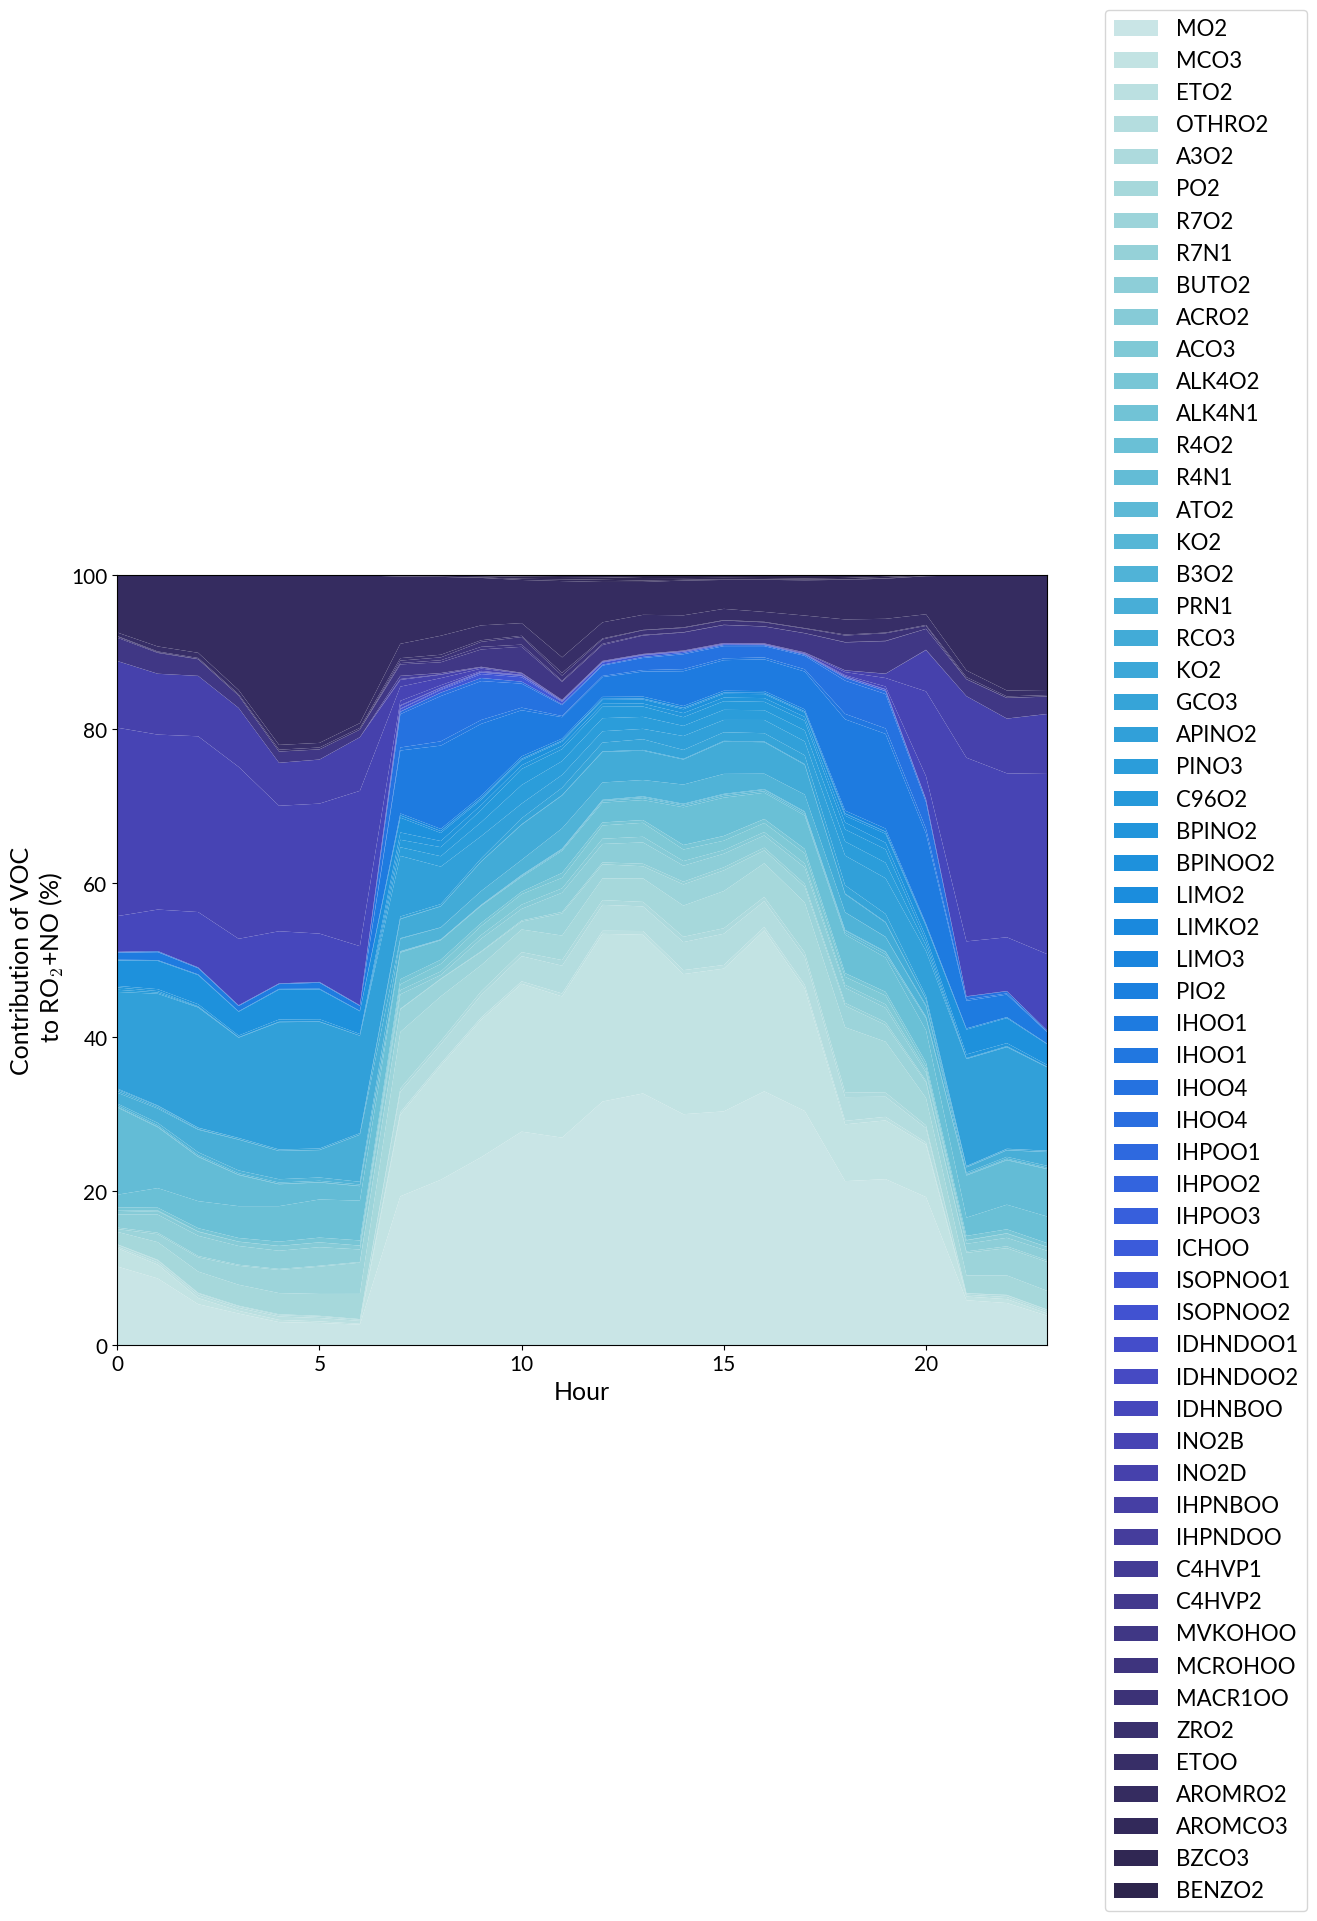

In [ ]:
hour_range = np.arange(0,24,1)
GEOSChem_VOC_labels=RO2_labels_geoschem

percent_contribution_all = []
for voc_spec in range(0,len(GEOSChem_VOC_labels)):
    percent_contribution_voc = (ozone_yaml_geoschem['RO2_NO_scaled_rates'][voc_spec]/sum_total_voc_prod)*100
    print(percent_contribution_voc)
    percent_contribution_all.append(percent_contribution_voc)
percent_contribution_array = np.array([percent_contribution_all])
percent_contribution_array_resize = np.squeeze(percent_contribution_array,axis=0)
print(np.shape(percent_contribution_array_resize))
fig, ax = plt.subplots(figsize = (12,10), layout = 'tight')
colors = cmr.take_cmap_colors('cmr.freeze_r', 59, cmap_range=(0.1, 0.8), return_fmt='hex')
plt.stackplot(hour_range, percent_contribution_array_resize, labels = GEOSChem_VOC_labels, colors = colors)
plt.legend(loc='center left',         # put legend on the left side of bbox_to_anchor
    bbox_to_anchor=(1.05, 0.5) # x=1.05 moves it outside; y=0.5 centers vertically
)

plt.margins(y=0)
plt.xlabel('Hour')
plt.ylabel('Contribution of VOC\n to RO$_2$+NO (%)')
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_precursor_ro2_no_GEOS-Chem.png', dpi =150,  bbox_inches='tight')
plt.show()


In [ ]:
print(len(cracmm_VOC_labels))

53


[ 5.18933345  5.56828895  3.33301087  2.16568485  2.01733955  2.39283072
  1.25685541 23.99731649 27.9075394  20.39244079 11.42106677  5.54757223
  5.45563647  6.35055035  8.71843011  7.94325185  9.03826293 11.48724624
 24.23092442 24.58875592 21.49500268 21.52974519 21.16647486 10.67752069]
[ 3.82752521  2.55917133  0.73280379  0.27553001  0.18499341  0.13655422
  0.07370978 12.75480764 16.37159112 22.54990737 28.8653202  28.63439542
 32.51331767 33.87936024 31.08380486 31.11621226 32.97576524 29.95019042
 20.43801954 20.03047419 15.60228103  1.15125123  0.90094582  0.38001435]
[0.69168047 0.79106724 0.61950325 0.55919376 0.58415719 0.6102953
 0.55334532 3.72010576 3.69044776 4.6691757  5.71324291 5.97262434
 5.97467173 5.98393636 6.06292586 7.05910212 6.21568436 6.32187816
 4.81847112 3.77007104 1.74706851 0.38329353 0.58697449 0.60352118]
[0.76602453 0.94264824 0.78061202 0.68359853 0.77591554 0.77859425
 0.6008575  0.97522768 0.98607383 1.16655831 1.21672212 2.74491005
 2.22177651 

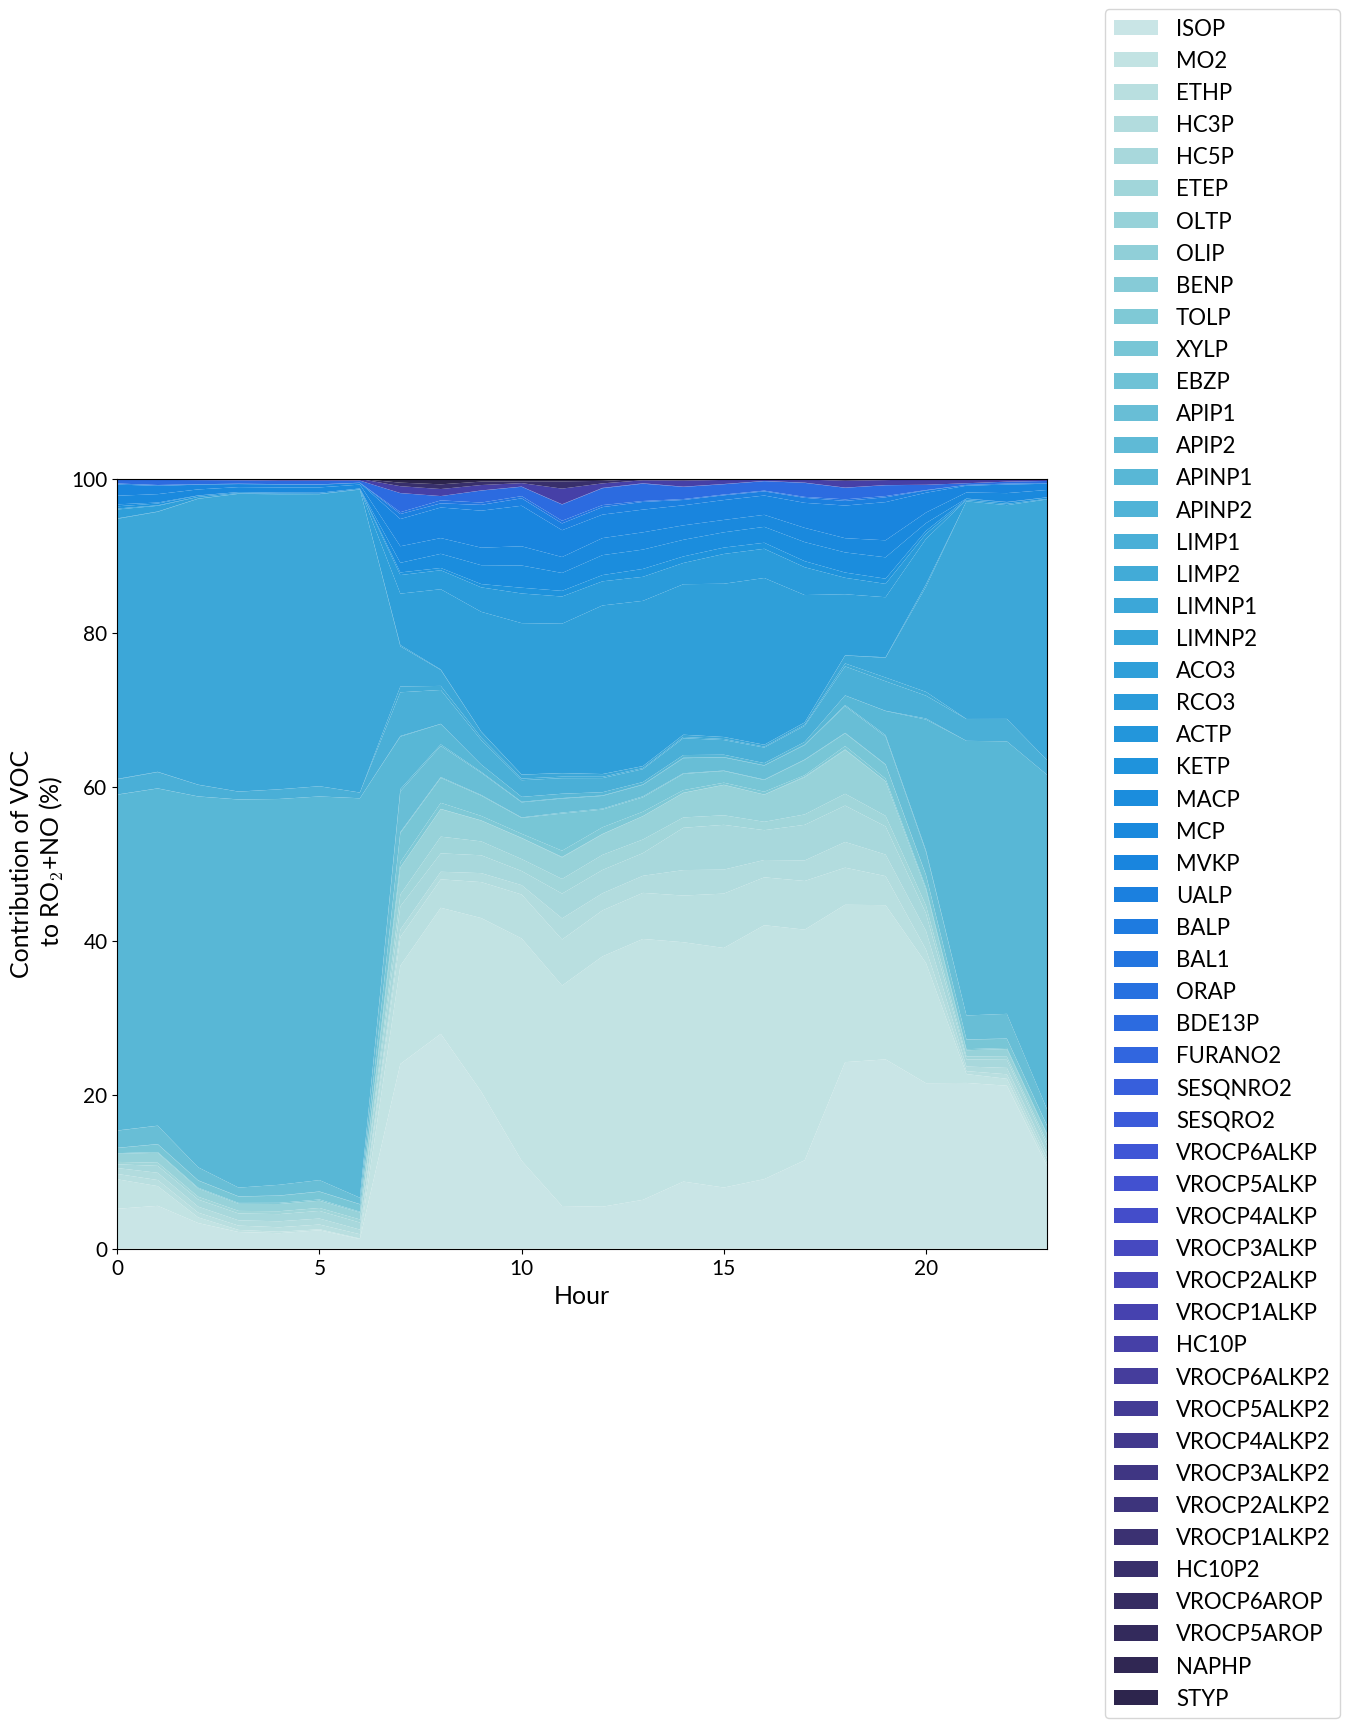

In [ ]:
hour_range = np.arange(0,24,1)
cracmm_VOC_labels=RO2_labels_cracmm
sum_total_voc_prod = np.sum(ozone_yaml_cracmm['RO2_NO_scaled_rates'],axis=0)
percent_contribution_all = []
for voc_spec in range(0,len(cracmm_VOC_labels)):
    percent_contribution_voc = (ozone_yaml_cracmm['RO2_NO_scaled_rates'][voc_spec]/sum_total_voc_prod)*100
    print(percent_contribution_voc)
    percent_contribution_all.append(percent_contribution_voc)
percent_contribution_array = np.array([percent_contribution_all])
percent_contribution_array_resize = np.squeeze(percent_contribution_array,axis=0)
print(np.shape(percent_contribution_array_resize))
fig, ax = plt.subplots(figsize = (12,10))
colors = cmr.take_cmap_colors('cmr.freeze_r', 53, cmap_range=(0.1, 0.8), return_fmt='hex')
plt.stackplot(hour_range, percent_contribution_array_resize, labels = cracmm_VOC_labels, colors = colors)
# plt.legend()
plt.legend(loc='center left',         # put legend on the left side of bbox_to_anchor
    bbox_to_anchor=(1.05, 0.5) # x=1.05 moves it outside; y=0.5 centers vertically
)

plt.margins(y=0)
plt.xlabel('Hour')
plt.ylabel('Contribution of VOC\n to RO$_2$+NO (%)')
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_precursor_ro2_no_CRACMM.png', dpi =150,  bbox_inches='tight')
plt.show()


In [ ]:
print(np.shape(percent_contribution_array))
print(np.shape(percent_contribution_array_resize))

(1, 53, 24)
(53, 24)


[3.18688178e+00 1.16988700e+00 3.69297768e-01 1.33803597e-01
 7.48976626e-02 4.11662452e-02 2.36177047e-02 1.71301277e+01
 2.08693128e+01 2.52123464e+01 2.86292869e+01 3.14799313e+01
 3.36011865e+01 3.18102216e+01 2.93749173e+01 2.92576952e+01
 2.96946798e+01 2.46362452e+01 1.25887275e+01 1.29526770e+01
 1.45883943e+01 6.28622195e-01 2.05179799e-01 8.61136767e-02]
[ 0.54920249  0.23116189  0.08395889  0.03623075  0.02796381  0.01967838
  0.01081124 10.10293657  7.11527921  6.44929233  6.37077195  6.26417167
  5.19248637  4.91508408  5.10433513  6.91504662  6.34327561  7.10895185
  6.18015559  5.13866927  2.64003394  0.21552342  0.08814106  0.0330642 ]
[91.80081404 95.89099417 97.33809061 97.67581105 97.88104125 97.80510838
 97.43066768 31.38917596 30.08033601 34.87283264 40.8452791  44.70942696
 47.51453498 49.00483236 47.35014066 47.60218466 48.47454308 47.85832863
 35.27486086 34.34465184 32.49659633 91.25111921 96.15376882 97.45967324]
[2.91998810e-05 7.20378375e-06 2.07371276e-06 8

/tmp/ipykernel_1049683/2662513178.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_precursor_ro2_no_CB6r5h.png', dpi =150,  bbox_inches='tight')


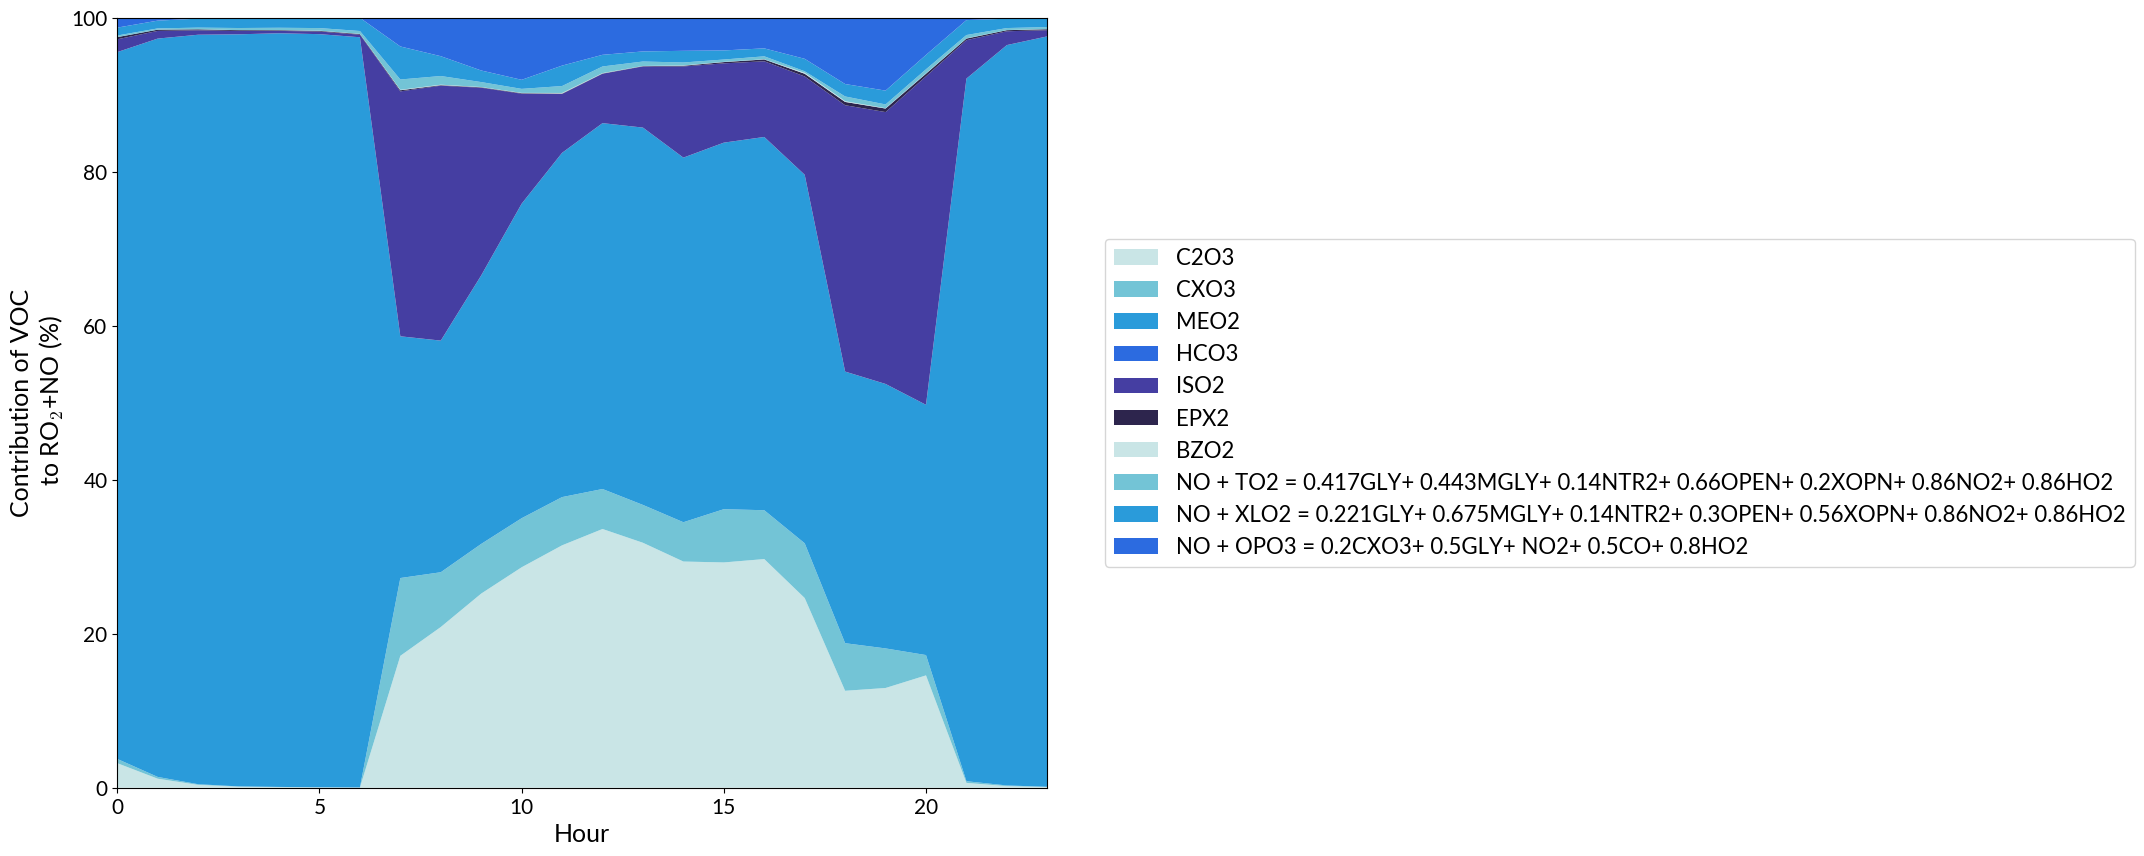

In [ ]:
hour_range = np.arange(0,24,1)
cb6r5h_VOC_labels=RO2_labels_cb6r5h
sum_total_voc_prod = np.sum(ozone_yaml_cb6r5h['RO2_NO_scaled_rates'],axis=0)
percent_contribution_all = []
for voc_spec in range(0,len(cb6r5h_VOC_labels)):
    percent_contribution_voc = (ozone_yaml_cb6r5h['RO2_NO_scaled_rates'][voc_spec]/sum_total_voc_prod)*100
    print(percent_contribution_voc)
    percent_contribution_all.append(percent_contribution_voc)
percent_contribution_array = np.array([percent_contribution_all])
percent_contribution_array_resize = np.squeeze(percent_contribution_array,axis=0)
print(np.shape(percent_contribution_array_resize))
fig, ax = plt.subplots(figsize = (12,10), layout = 'tight')
colors = cmr.take_cmap_colors('cmr.freeze_r', 6, cmap_range=(0.1, 0.8), return_fmt='hex')
plt.stackplot(hour_range, percent_contribution_array_resize, labels = cb6r5h_VOC_labels, colors = colors)
plt.legend(loc='center left',         # put legend on the left side of bbox_to_anchor
    bbox_to_anchor=(1.05, 0.5) # x=1.05 moves it outside; y=0.5 centers vertically
)

plt.margins(y=0)
plt.xlabel('Hour')
plt.ylabel('Contribution of VOC\n to RO$_2$+NO (%)')
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_precursor_ro2_no_CB6r5h.png', dpi =150,  bbox_inches='tight')
plt.show()


# OPE Comparison

In [ ]:
# print(ozone_yaml_geoschem.keys())
# print(ozone_yaml_geoschem['RO2_NO_conversion_rxns'])

RO2_labels_geoschem = []
RO2_labels_cb6r5h = []

for rxn in ozone_yaml_geoschem['RO2_NO_conversion_rxns']:
    species = rxn.split('+NO')[0]
    RO2_labels_geoschem.append(species)

print(RO2_labels_geoschem)

['MO2', 'MCO3', 'ETO2', 'OTHRO2', 'A3O2', 'PO2', 'R7O2', 'R7N1', 'BUTO2', 'ACRO2', 'ACO3', 'ALK4O2', 'ALK4N1', 'R4O2', 'R4N1', 'ATO2', 'KO2', 'B3O2', 'PRN1', 'RCO3', 'KO2', 'GCO3', 'APINO2', 'PINO3', 'C96O2', 'BPINO2', 'BPINOO2', 'LIMO2', 'LIMKO2', 'LIMO3', 'PIO2', 'IHOO1', 'IHOO1', 'IHOO4', 'IHOO4', 'IHPOO1', 'IHPOO2', 'IHPOO3', 'ICHOO', 'ISOPNOO1', 'ISOPNOO2', 'IDHNDOO1', 'IDHNDOO2', 'IDHNBOO', 'INO2B', 'INO2D', 'IHPNBOO', 'IHPNDOO', 'C4HVP1', 'C4HVP2', 'MVKOHOO', 'MCROHOO', 'MACR1OO', 'ZRO2', 'ETOO', 'AROMRO2', 'AROMCO3', 'BZCO3', 'BENZO2']
['ISOP + NO = 0.13000*ISON +  0.40000*HCHO +  0.88000*HO2 +  0.87000*NO2 +  0.18000*MACR +  0.51000*MVK ', 'MO2 + NO = HO2 + NO2 + HCHO ', 'ETHP + NO = HO2 + NO2 + ACD ', 'HC3P + NO = 0.66000*HO2 +  0.13100*MO2 +  0.04800*ETHP +  0.08900*XO2 +  0.93500*NO2 +  0.50400*ACD +  0.13200*ALD +  0.16500*ACT +  0.04200*MEK +  0.06500*ONIT ', 'HC5P + NO = 0.20000*HO2 +  0.05100*MO2 +  0.23100*ETHP +  0.23500*XO2 +  0.86400*NO2 +  0.01800*HCHO +  0.04500*A

In [ ]:
RO2_labels_cracmm = []
for rxn in ozone_yaml_cracmm['RO2_NO_conversion_rxns']:
    species = rxn.split(' + NO')[0]
    RO2_labels_cracmm.append(species)

print(RO2_labels_cracmm)

['ISOP', 'MO2', 'ETHP', 'HC3P', 'HC5P', 'ETEP', 'OLTP', 'OLIP', 'BENP', 'TOLP', 'XYLP', 'EBZP', 'APIP1', 'APIP2', 'APINP1', 'APINP2', 'LIMP1', 'LIMP2', 'LIMNP1', 'LIMNP2', 'ACO3', 'RCO3', 'ACTP', 'KETP', 'MACP', 'MCP', 'MVKP', 'UALP', 'BALP', 'BAL1', 'ORAP', 'BDE13P', 'FURANO2', 'SESQNRO2', 'SESQRO2', 'VROCP6ALKP', 'VROCP5ALKP', 'VROCP4ALKP', 'VROCP3ALKP', 'VROCP2ALKP', 'VROCP1ALKP', 'HC10P', 'VROCP6ALKP2', 'VROCP5ALKP2', 'VROCP4ALKP2', 'VROCP3ALKP2', 'VROCP2ALKP2', 'VROCP1ALKP2', 'HC10P2', 'VROCP6AROP', 'VROCP5AROP', 'NAPHP', 'STYP']


In [ ]:
RO2_labels_cb6r5h = []

for rxn in ozone_yaml_cb6r5h['RO2_NO_conversion_rxns']:
    species = rxn.split(' + NO')[0]
    RO2_labels_cb6r5h.append(species)

print(RO2_labels_cb6r5h)

['C2O3', 'CXO3', 'MEO2', 'HCO3', 'ISO2', 'EPX2', 'BZO2', 'NO + TO2 = 0.417GLY+ 0.443MGLY+ 0.14NTR2+ 0.66OPEN+ 0.2XOPN+ 0.86NO2+ 0.86HO2', 'NO + XLO2 = 0.221GLY+ 0.675MGLY+ 0.14NTR2+ 0.3OPEN+ 0.56XOPN+ 0.86NO2+ 0.86HO2', 'NO + OPO3 = 0.2CXO3+ 0.5GLY+ NO2+ 0.5CO+ 0.8HO2']


(17, 24)
(24,)
[6.31121204e-04 6.74197159e-04 1.01906155e-03 1.56605191e-03
 8.42200219e-04 9.65948528e-04 1.58086639e-03 4.94125347e+00
 8.95771377e+00 1.52689165e+01 1.55656106e+01 1.46301628e+01
 1.71885960e+01 1.71108080e+01 1.73349129e+01 1.68897618e+01
 1.80152167e+01 1.65280215e+01 1.03942188e+01 6.88446736e+00
 2.31191488e+00 6.33009284e-04 5.94499062e-04 1.12356464e-03]
[1.16586240e-05 1.51353873e-05 3.30874300e-05 5.35751786e-05
 3.65135593e-05 4.05278450e-05 5.68564926e-05 1.99976839e-02
 2.62637147e-02 5.71076220e-02 8.30628317e-02 1.12108762e-01
 1.33505319e-01 1.72529019e-01 2.02010353e-01 2.19876049e-01
 1.96603774e-01 2.04965964e-01 1.77109024e-01 1.13518562e-01
 2.46689347e-02 2.02684608e-05 2.66076409e-05 6.30671029e-05]
[1.04120618e-04 1.82531955e-04 5.00453195e-04 9.20679183e-04
 6.58355291e-04 8.00810944e-04 9.50433399e-04 4.77177990e-01
 1.99994852e-01 1.01667884e+00 8.40229232e-01 1.35426061e+00
 1.30031464e+00 1.44648146e+00 1.19849395e+00 9.81676989e-01
 8.6327

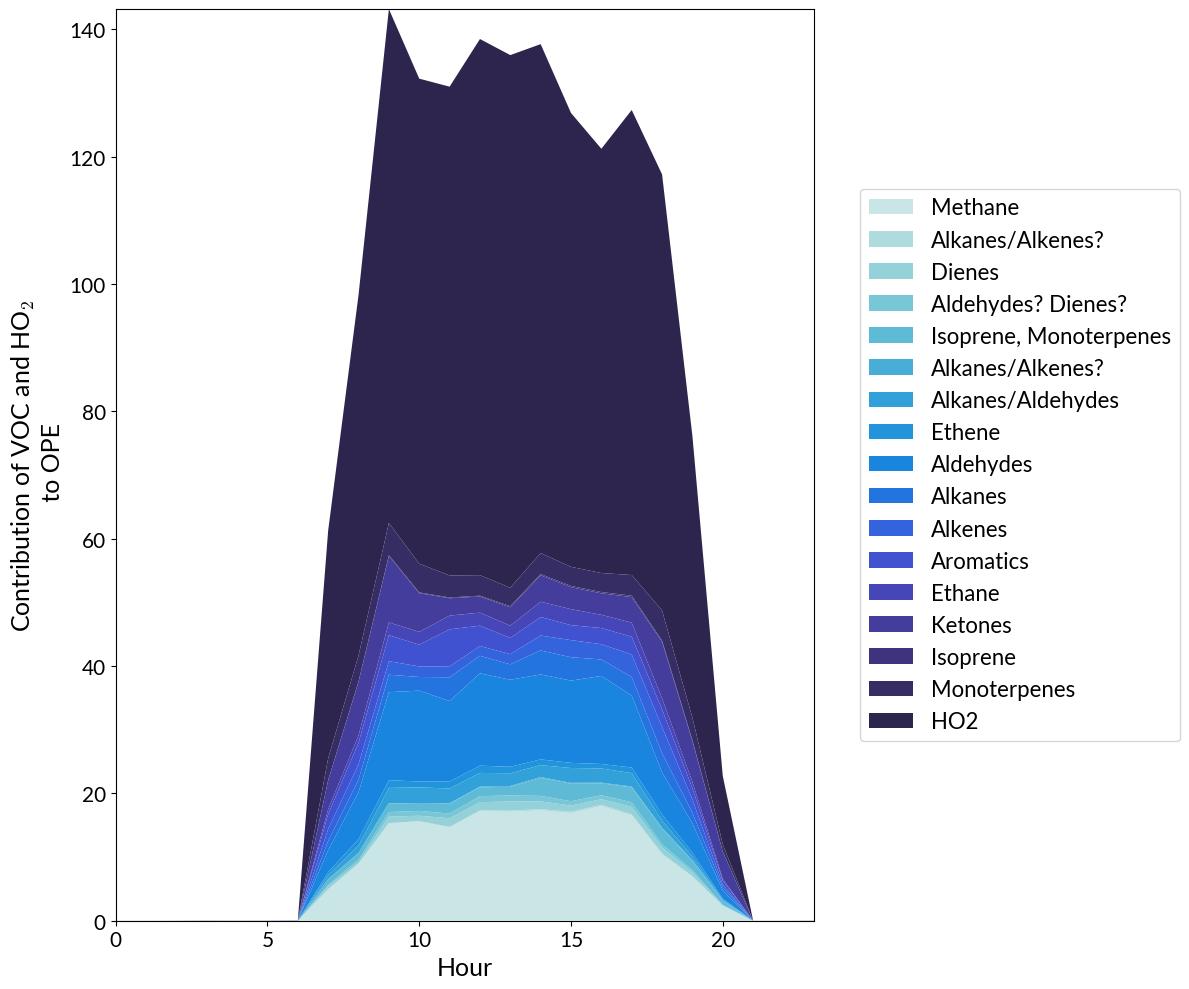

In [ ]:
hour_range = np.arange(0,24,1)
GEOSChem_VOC_labels=['Methane', 'Alkanes/Alkenes?', 'Dienes', 'Aldehydes? Dienes?','Isoprene, Monoterpenes', 'Alkanes/Alkenes?', 'Alkanes/Aldehydes','Ethene', 'Aldehydes', 'Alkanes','Alkenes', 'Aromatics', 'Ethane', 'Ketones', 'Isoprene', 'Monoterpenes', 'HO2']
# print(type(ozone_yaml_geoschem['grouped_voc_ozone_production']))
ozone_yaml_geoschem['grouped_voc_ozone_production'].append(ozone_yaml_geoschem['HO2_NO_rate'])
grouped_vocs_geoschem = np.array(ozone_yaml_geoschem['grouped_voc_ozone_production'])
loss_nox = np.array(ozone_yaml_geoschem['lost_NOx_sum_rates'])
print(np.shape(grouped_vocs_geoschem))
print(np.shape(loss_nox))

np.sum(grouped_vocs_geoschem,axis=0)
percent_contribution_all = []
for voc_spec in range(0,17):
    percent_contribution_voc = (grouped_vocs_geoschem[voc_spec]/loss_nox)*100
    print(percent_contribution_voc)
    percent_contribution_all.append(percent_contribution_voc)
percent_contribution_array = np.array([percent_contribution_all])
percent_contribution_array_resize = np.squeeze(percent_contribution_array,axis=0)

fig, ax = plt.subplots(figsize = (12,10), layout = 'tight')
colors = cmr.take_cmap_colors('cmr.freeze_r', 17, cmap_range=(0.1, 0.8), return_fmt='hex')
plt.stackplot(hour_range, percent_contribution_array_resize, labels = GEOSChem_VOC_labels, colors = colors)
plt.legend(loc='center left',         # put legend on the left side of bbox_to_anchor
    bbox_to_anchor=(1.05, 0.5) # x=1.05 moves it outside; y=0.5 centers vertically
)

plt.margins(y=0)
plt.xlabel('Hour')
plt.ylabel('Contribution of VOC and HO$_2$\n to OPE')
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_and_ho2_contribution_ope_GEOS-Chem.png', dpi =150)
plt.show()


(14, 24)
(24,)
[2.27628248e-04 3.20485978e-04 4.33941888e-04 4.28934172e-04
 4.06940613e-04 5.08937159e-04 3.44727602e-04 5.80717174e+00
 1.00492764e+01 1.03989871e+01 5.48686208e+00 2.69331397e+00
 2.79124531e+00 3.29354849e+00 4.95236411e+00 4.46345920e+00
 5.08501962e+00 6.31629610e+00 1.13146433e+01 8.01876834e+00
 2.75850827e+00 2.03384661e-03 1.91300008e-03 1.74035561e-03]
[1.67893019e-04 1.47294534e-04 9.54075081e-05 5.45712990e-05
 3.73171356e-05 2.90440584e-05 2.02169599e-05 3.08656839e+00
 5.89527587e+00 1.14991725e+01 1.38673588e+01 1.39018320e+01
 1.66346578e+01 1.75706529e+01 1.76566558e+01 1.74847716e+01
 1.85525045e+01 1.64682002e+01 9.54354431e+00 6.53224314e+00
 2.00228034e+00 1.08755045e-04 8.14263798e-05 6.19394830e-05]
[3.03403156e-05 4.55303165e-05 8.06563254e-05 1.10753562e-04
 1.17837022e-04 1.29805235e-04 1.51770365e-04 9.00237868e-01
 1.32890001e+00 2.38101452e+00 2.74473274e+00 2.89967429e+00
 3.05679723e+00 3.10341364e+00 3.44394760e+00 3.96663922e+00
 3.4970

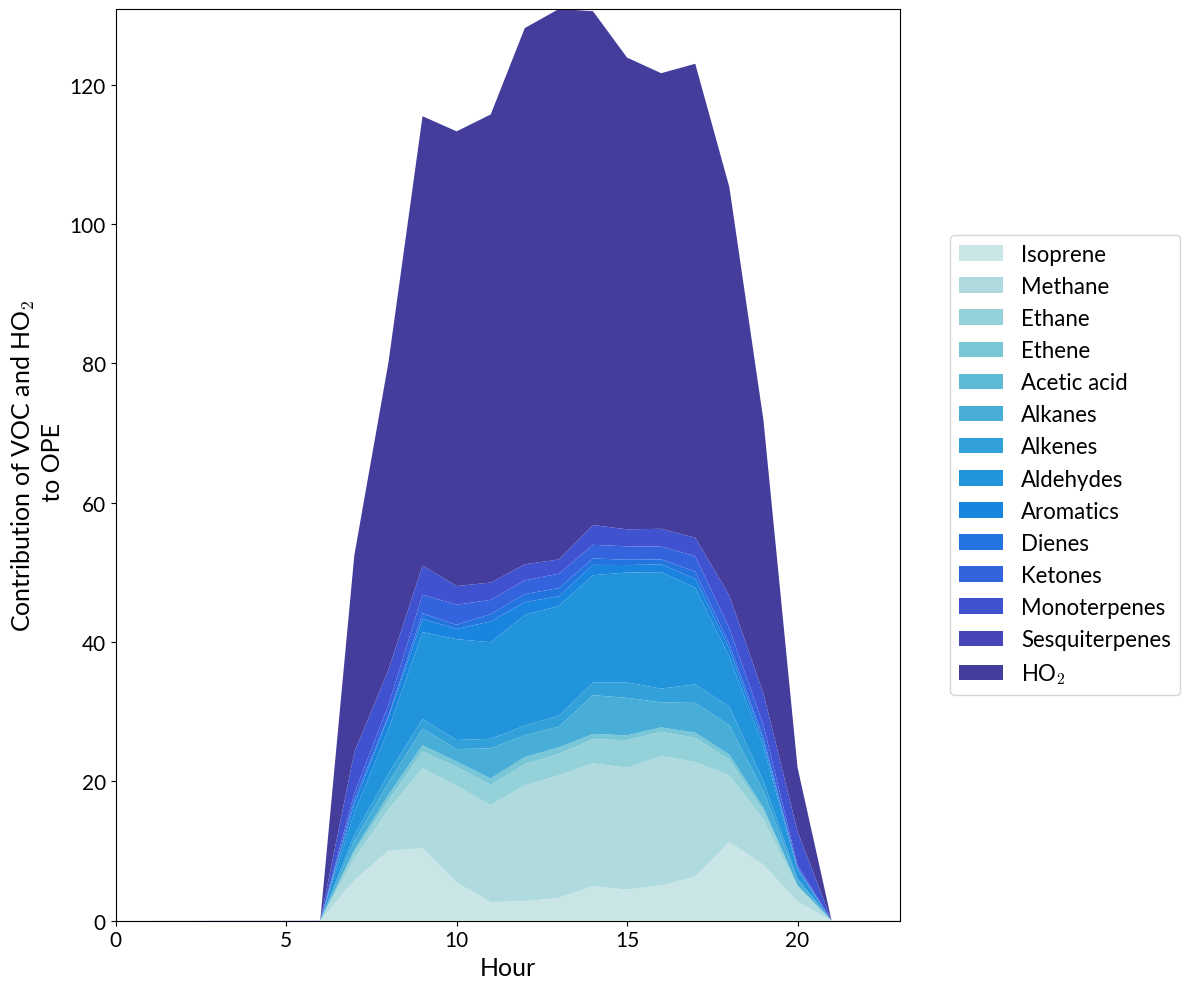

In [ ]:
hour_range = np.arange(0,24,1)
CRACMM_VOC_labels=['Isoprene', 'Methane', 'Ethane', 'Ethene', 'Acetic acid', 'Alkanes', 'Alkenes', 'Aldehydes', 'Aromatics', 'Dienes', 'Ketones', 'Monoterpenes', 'Sesquiterpenes', 'HO$_2$']# print(type(ozone_yaml_cracmm['grouped_voc_ozone_production']))
ozone_yaml_cracmm['grouped_voc_ozone_production'].append(ozone_yaml_cracmm['HO2_NO_rate'])
grouped_vocs_cracmm = np.array(ozone_yaml_cracmm['grouped_voc_ozone_production'])
loss_nox = np.array(ozone_yaml_cracmm['lost_NOx_sum_rates'])
print(np.shape(grouped_vocs_cracmm))
print(np.shape(loss_nox))

np.sum(grouped_vocs_cracmm,axis=0)
percent_contribution_all = []
for voc_spec in range(0,14):
    percent_contribution_voc = (grouped_vocs_cracmm[voc_spec]/loss_nox)*100
    print(percent_contribution_voc)
    percent_contribution_all.append(percent_contribution_voc)
percent_contribution_array = np.array([percent_contribution_all])
percent_contribution_array_resize = np.squeeze(percent_contribution_array,axis=0)

fig, ax = plt.subplots(figsize = (12,10), layout = 'tight')
colors = cmr.take_cmap_colors('cmr.freeze_r', 17, cmap_range=(0.1, 0.8), return_fmt='hex')
plt.stackplot(hour_range, percent_contribution_array_resize, labels = CRACMM_VOC_labels, colors = colors)
plt.legend(loc='center left',         # put legend on the left side of bbox_to_anchor
    bbox_to_anchor=(1.05, 0.5) # x=1.05 moves it outside; y=0.5 centers vertically
)

plt.margins(y=0)
plt.xlabel('Hour')
plt.ylabel('Contribution of VOC and HO$_2$\n to OPE')
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_and_ho2_contribution_ope_cracmm.png', dpi =150)
plt.show()


(6, 24)
(24,)
[1.34599852e-03 2.36454551e-03 3.39815045e-03 3.62406305e-03
 3.23433998e-03 3.33754658e-03 3.21951591e-03 3.43501303e+00
 7.14492501e+00 1.67099877e+01 2.07501281e+01 2.21483631e+01
 2.48625540e+01 2.83944454e+01 3.04422072e+01 2.95344618e+01
 3.18348285e+01 2.92025120e+01 1.76424925e+01 1.04861646e+01
 2.35741529e+00 1.34259263e-03 2.33474380e-03 3.71786097e-03]
[4.28133420e-10 1.77635811e-10 7.23949680e-11 3.04339321e-11
 1.50909574e-11 1.05430751e-11 6.94825504e-12 4.52385760e-04
 6.28926026e-04 9.97889672e-04 9.47532834e-04 9.21081670e-04
 8.73454282e-04 9.16388637e-04 8.36866969e-04 7.23598940e-04
 5.93629528e-04 6.24089989e-04 7.52287308e-04 5.54229504e-04
 1.53086444e-04 1.07938075e-10 5.33533189e-11 3.38248358e-11]
[5.47790772e-05 3.45480186e-05 1.58235517e-05 6.30877976e-06
 3.39891118e-06 2.07629003e-06 1.13767596e-06 2.98019709e+00
 6.64712694e+00 1.51712824e+01 1.77806522e+01 1.86978487e+01
 2.02992576e+01 2.12794257e+01 2.21672952e+01 2.24431393e+01
 2.36673

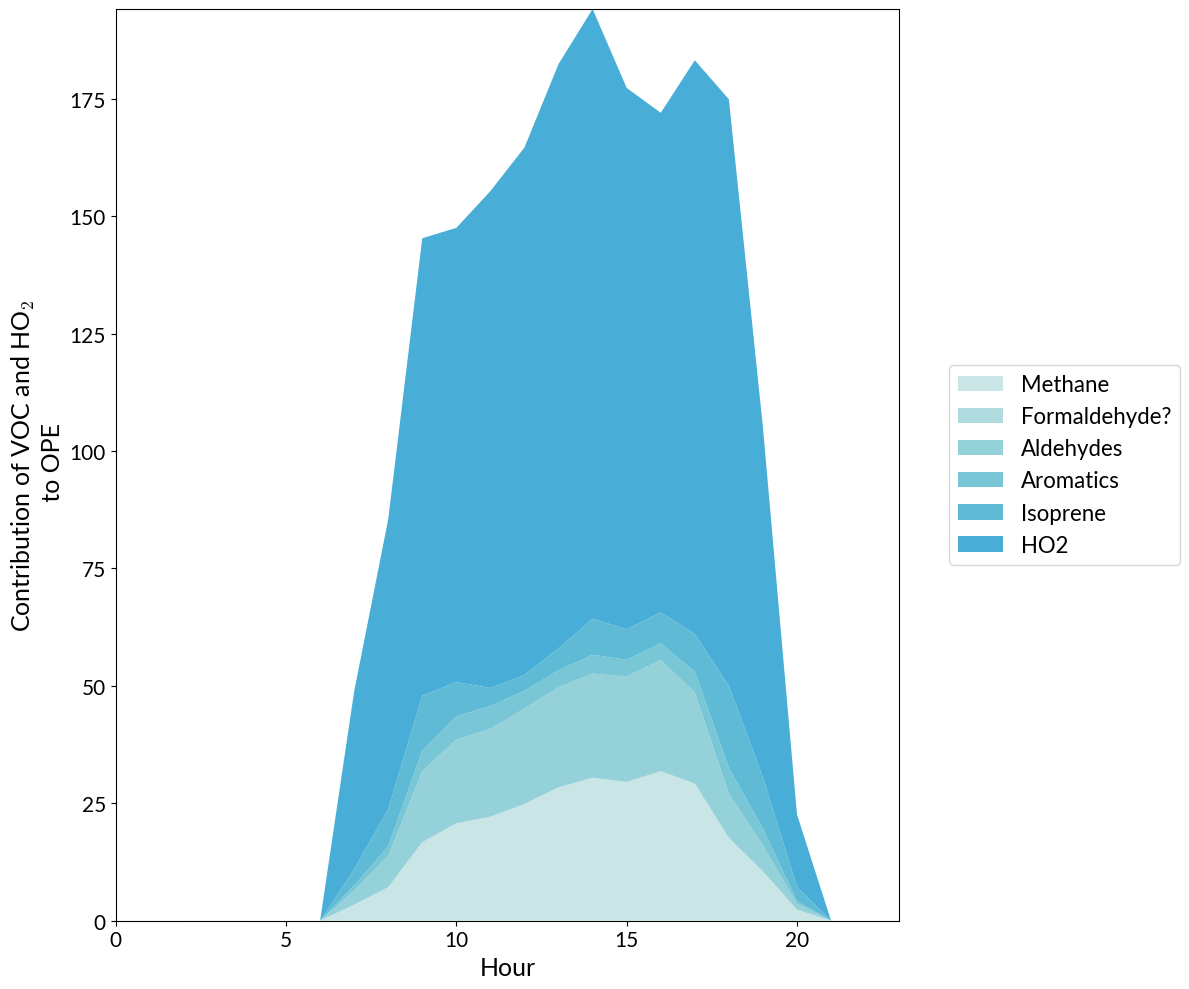

In [ ]:
hour_range = np.arange(0,24,1)
cb6r5h_VOC_labels=['Methane', 'Formaldehyde?','Aldehydes','Aromatics', 'Isoprene', 'HO2']
# print(type(ozone_yaml_cb6r5h['grouped_voc_ozone_production']))
ozone_yaml_cb6r5h['grouped_voc_ozone_production'].append(ozone_yaml_cb6r5h['HO2_NO_rate'])
grouped_vocs_cb6r5h = np.array(ozone_yaml_cb6r5h['grouped_voc_ozone_production'])
loss_nox = np.array(ozone_yaml_cb6r5h['lost_NOx_sum_rates'])
print(np.shape(grouped_vocs_cb6r5h))
print(np.shape(loss_nox))

np.sum(grouped_vocs_cb6r5h,axis=0)
percent_contribution_all = []
for voc_spec in range(0,6):
    percent_contribution_voc = (grouped_vocs_cb6r5h[voc_spec]/loss_nox)*100
    print(percent_contribution_voc)
    percent_contribution_all.append(percent_contribution_voc)
percent_contribution_array = np.array([percent_contribution_all])
percent_contribution_array_resize = np.squeeze(percent_contribution_array,axis=0)

fig, ax = plt.subplots(figsize = (12,10), layout = 'tight')
colors = cmr.take_cmap_colors('cmr.freeze_r', 17, cmap_range=(0.1, 0.8), return_fmt='hex')
plt.stackplot(hour_range, percent_contribution_array_resize, labels = cb6r5h_VOC_labels, colors = colors)
plt.legend(loc='center left',         # put legend on the left side of bbox_to_anchor
    bbox_to_anchor=(1.05, 0.5) # x=1.05 moves it outside; y=0.5 centers vertically
)

plt.margins(y=0)
plt.xlabel('Hour')
plt.ylabel('Contribution of VOC and HO$_2$\n to OPE')
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/voc_and_ho2_contribution_ope_CB6r5h.png', dpi =150)
plt.show()


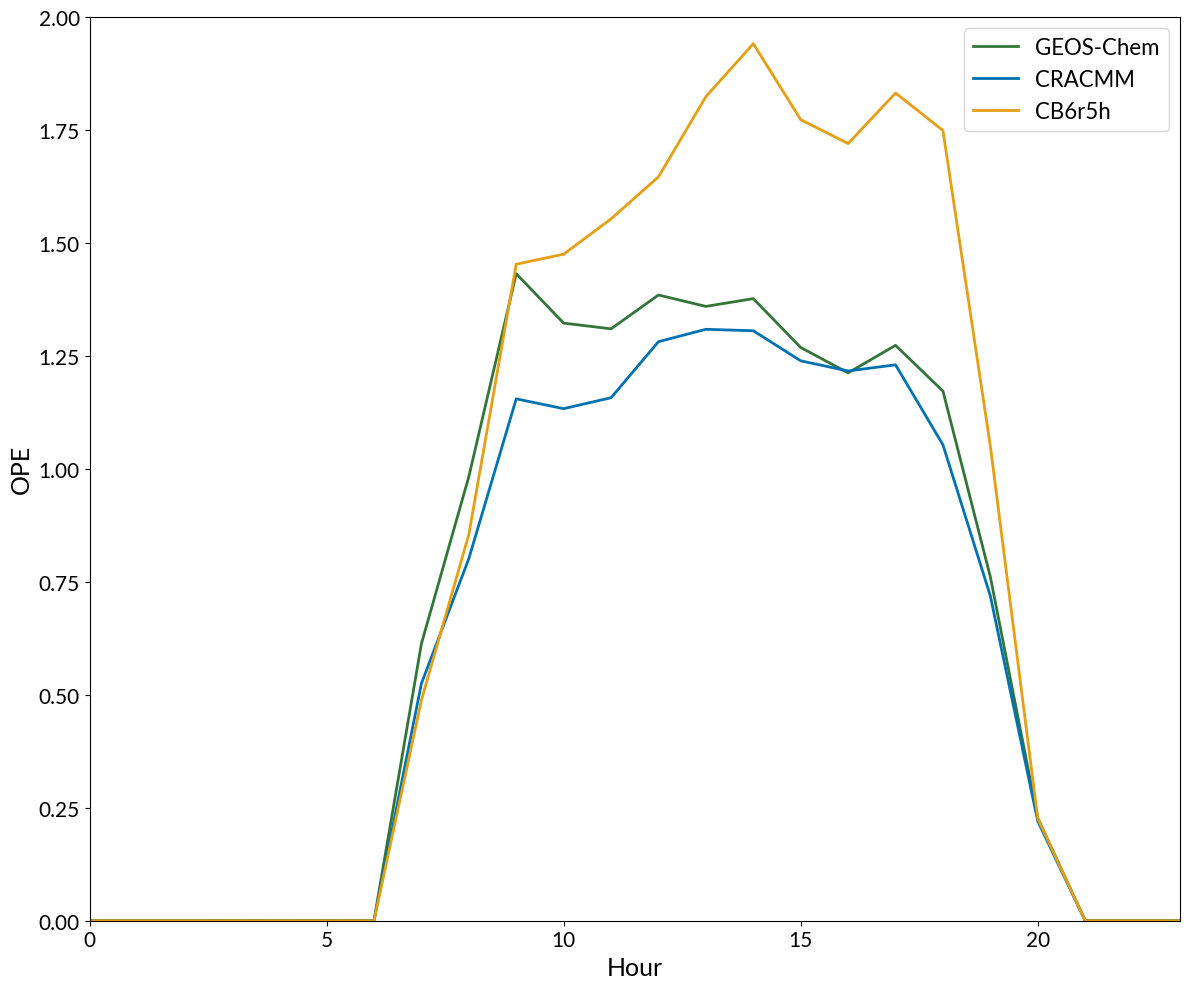

In [ ]:
fig, ax = plt.subplots(figsize = (12,10), layout = 'tight')
plt.plot(hour_range, ozone_yaml_geoschem['ope_total'], label = 'GEOS-Chem', linewidth = 2, color = trio_colorset1[0].tolist())
plt.plot(hour_range, ozone_yaml_cracmm['ope_total'], label = 'CRACMM', linewidth = 2, color = trio_colorset1[1].tolist())
plt.plot(hour_range, ozone_yaml_cb6r5h['ope_total'], label = 'CB6r5h',linewidth = 2, color = trio_colorset1[2].tolist())
plt.legend()
plt.margins(x=0,y=0)
plt.xlabel('Hour')
plt.ylabel('OPE')
plt.ylim([0,2])
plt.savefig(dirpath + 'Plotting/For_F0AM_runs/plots/ope_comparison.png', dpi =150)
plt.show()
